In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import heapq
from math import log
from sklearn import metrics
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from keras.models import Sequential, Model
from keras.layers import Input,Dense,Reshape,Flatten,Concatenate,Conv1D,MaxPool1D,Dropout,BatchNormalization
from keras.layers import LeakyReLU
from tensorflow.keras.optimizers import Adam
from keras.utils import plot_model
from sklearn.metrics import r2_score,mean_squared_error,precision_score,recall_score,f1_score,accuracy_score,roc_curve,auc
import matplotlib.pyplot as plt
%matplotlib inline
from keras import backend as K
from keras.layers import Activation
import os
import time
import json
import pickle
import random
import math
from decimal import Decimal
import matplotlib.mlab as mlab
from scipy import stats
from pylab import rcParams
from sklearn.utils import check_random_state
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from keras.callbacks import EarlyStopping

In [3]:
# Core layers
from keras.layers import Activation, Dropout, Flatten, Dense, Input, LeakyReLU

# Normalization layers
from keras.layers import BatchNormalization

# Merge layers
from keras.layers import concatenate, multiply

# Embedding Layers
from keras.layers import Embedding

# Keras models
from keras.models import Model, Sequential

# Keras optimizers
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

### 数据

In [30]:
train_data = pd.read_excel(r'D:\creep rupture\TR+TS\normalizedtrainingdataTF.xlsx')
test_data = pd.read_excel(r'D:\creep rupture\TR+TS\normalizedtestingdataTF.xlsx')
train_data = train_data.dropna(subset=['Tensile strength'])
test_data = test_data.dropna(subset=['Tensile strength'])

In [31]:
x=train_data[['Si', 'N', 'χ','Aus','TT','0.2% PS', 'Elongation(%)', 'Reduction of Area(%)', 'Ts']]
y=train_data['Tensile strength']

In [32]:
x_test=test_data[['Si', 'N', 'χ','Aus','TT' ,'0.2% PS', 'Elongation(%)', 'Reduction of Area(%)', 'Ts']]
y_test=test_data['Tensile strength']

### SVM

In [33]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

svr = SVR()
scores = cross_val_score(svr, x, y, cv=10, scoring='r2')
print("交叉验证得分:", scores)
print("平均交叉验证得分: {:.2f}".format(scores.mean()))

# 在整个训练集上拟合模型
svr.fit(x, y)

# 在测试集上进行预测
y_pred = svr.predict(x_test)

交叉验证得分: [0.90608399 0.86850995 0.88628975 0.88769467 0.92622768 0.87712077
 0.84070898 0.80034191 0.88486342 0.88415892]
平均交叉验证得分: 0.88


### RF

In [34]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor()

# 进行交叉验证
scores = cross_val_score(rf, x, y, cv=10)
print("交叉验证得分: {}".format(scores))
print("平均交叉验证得分: {:.2f}".format(scores.mean()))
print("{:.2f}% (+/- {:.2f}%)".format(scores.mean() * 100, scores.std() * 100))

# 在整个训练集上拟合模型
rf.fit(x, y)

# 在测试集上进行预测
y_pred = rf.predict(x_test)

交叉验证得分: [0.97839943 0.94957362 0.95800778 0.98376332 0.9912983  0.9407321
 0.96970773 0.94871386 0.9529472  0.9376516 ]
平均交叉验证得分: 0.96
96.11% (+/- 1.77%)


### DT

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

dt = DecisionTreeRegressor()
scores = cross_val_score(dt, x, y, cv=10, scoring='r2')
print("交叉验证得分:", scores)
print("平均交叉验证得分: {:.2f}".format(scores.mean()))

# 在整个训练集上拟合模型
dt.fit(x, y)

# 在测试集上进行预测
y_pred = dt.predict(x_test)

交叉验证得分: [0.95710024 0.91248511 0.92955004 0.98994003 0.98834809 0.93621985
 0.93395048 0.91969614 0.88905946 0.85173178]
平均交叉验证得分: 0.93


### ANN

In [38]:
from tensorflow import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


Epoch 1/500
10/10 - 1s - loss: 0.0961 - mean_squared_error: 0.0961 - val_loss: 0.0183 - val_mean_squared_error: 0.0183 - 506ms/epoch - 51ms/step
Epoch 2/500
10/10 - 0s - loss: 0.0243 - mean_squared_error: 0.0243 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 34ms/epoch - 3ms/step
Epoch 3/500
10/10 - 0s - loss: 0.0173 - mean_squared_error: 0.0173 - val_loss: 0.0097 - val_mean_squared_error: 0.0097 - 33ms/epoch - 3ms/step
Epoch 4/500
10/10 - 0s - loss: 0.0161 - mean_squared_error: 0.0161 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 31ms/epoch - 3ms/step
Epoch 5/500
10/10 - 0s - loss: 0.0143 - mean_squared_error: 0.0143 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 34ms/epoch - 3ms/step
Epoch 6/500
10/10 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 31ms/epoch - 3ms/step
Epoch 7/500
10/10 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 36ms/epoch - 4ms/st

Epoch 58/500
10/10 - 0s - loss: 0.0028 - mean_squared_error: 0.0028 - val_loss: 0.0052 - val_mean_squared_error: 0.0052 - 68ms/epoch - 7ms/step
Epoch 59/500
10/10 - 0s - loss: 0.0028 - mean_squared_error: 0.0028 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 79ms/epoch - 8ms/step
Epoch 60/500
10/10 - 0s - loss: 0.0028 - mean_squared_error: 0.0028 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 52ms/epoch - 5ms/step
Epoch 61/500
10/10 - 0s - loss: 0.0026 - mean_squared_error: 0.0026 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 52ms/epoch - 5ms/step
Epoch 62/500
10/10 - 0s - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 52ms/epoch - 5ms/step
Epoch 63/500
10/10 - 0s - loss: 0.0028 - mean_squared_error: 0.0028 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 49ms/epoch - 5ms/step
Epoch 64/500
10/10 - 0s - loss: 0.0026 - mean_squared_error: 0.0026 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 39ms/epoch - 4

Epoch 115/500
10/10 - 0s - loss: 0.0019 - mean_squared_error: 0.0019 - val_loss: 0.0013 - val_mean_squared_error: 0.0013 - 39ms/epoch - 4ms/step
Epoch 116/500
10/10 - 0s - loss: 0.0018 - mean_squared_error: 0.0018 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 36ms/epoch - 4ms/step
Epoch 117/500
10/10 - 0s - loss: 0.0020 - mean_squared_error: 0.0020 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 46ms/epoch - 5ms/step
Epoch 118/500
10/10 - 0s - loss: 0.0021 - mean_squared_error: 0.0021 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 27ms/epoch - 3ms/step
Epoch 119/500
10/10 - 0s - loss: 0.0018 - mean_squared_error: 0.0018 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 52ms/epoch - 5ms/step
Epoch 120/500
10/10 - 0s - loss: 0.0019 - mean_squared_error: 0.0019 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 30ms/epoch - 3ms/step
Epoch 121/500
10/10 - 0s - loss: 0.0020 - mean_squared_error: 0.0020 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 30ms/ep

Epoch 172/500
10/10 - 0s - loss: 0.0017 - mean_squared_error: 0.0017 - val_loss: 0.0012 - val_mean_squared_error: 0.0012 - 31ms/epoch - 3ms/step
Epoch 173/500
10/10 - 0s - loss: 0.0017 - mean_squared_error: 0.0017 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 37ms/epoch - 4ms/step
Epoch 174/500
10/10 - 0s - loss: 0.0016 - mean_squared_error: 0.0016 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 35ms/epoch - 3ms/step
Epoch 175/500
10/10 - 0s - loss: 0.0019 - mean_squared_error: 0.0019 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 42ms/epoch - 4ms/step
Epoch 176/500
10/10 - 0s - loss: 0.0015 - mean_squared_error: 0.0015 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 35ms/epoch - 4ms/step
Epoch 177/500
10/10 - 0s - loss: 0.0019 - mean_squared_error: 0.0019 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 35ms/epoch - 3ms/step
Epoch 178/500
10/10 - 0s - loss: 0.0016 - mean_squared_error: 0.0016 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 55ms/ep

Epoch 229/500
10/10 - 0s - loss: 0.0016 - mean_squared_error: 0.0016 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 36ms/epoch - 4ms/step
Epoch 230/500
10/10 - 0s - loss: 0.0017 - mean_squared_error: 0.0017 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 30ms/epoch - 3ms/step
Epoch 231/500
10/10 - 0s - loss: 0.0015 - mean_squared_error: 0.0015 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 35ms/epoch - 4ms/step
Epoch 232/500
10/10 - 0s - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 0.0013 - val_mean_squared_error: 0.0013 - 24ms/epoch - 2ms/step
Epoch 233/500
10/10 - 0s - loss: 0.0013 - mean_squared_error: 0.0013 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 29ms/epoch - 3ms/step
Epoch 234/500
10/10 - 0s - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 27ms/epoch - 3ms/step
Epoch 235/500
10/10 - 0s - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 26ms/ep

Epoch 286/500
10/10 - 0s - loss: 0.0013 - mean_squared_error: 0.0013 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 37ms/epoch - 4ms/step
Epoch 287/500
10/10 - 0s - loss: 0.0012 - mean_squared_error: 0.0012 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 36ms/epoch - 4ms/step
Epoch 288/500
10/10 - 0s - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 36ms/epoch - 4ms/step
Epoch 289/500
10/10 - 0s - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 43ms/epoch - 4ms/step
Epoch 290/500
10/10 - 0s - loss: 0.0015 - mean_squared_error: 0.0015 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 42ms/epoch - 4ms/step
Epoch 291/500
10/10 - 0s - loss: 0.0012 - mean_squared_error: 0.0012 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 43ms/epoch - 4ms/step
Epoch 292/500
10/10 - 0s - loss: 0.0013 - mean_squared_error: 0.0013 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 52ms/ep

Epoch 343/500
10/10 - 0s - loss: 0.0013 - mean_squared_error: 0.0013 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 30ms/epoch - 3ms/step
Epoch 344/500
10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 30ms/epoch - 3ms/step
Epoch 345/500
10/10 - 0s - loss: 0.0012 - mean_squared_error: 0.0012 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 37ms/epoch - 4ms/step
Epoch 346/500
10/10 - 0s - loss: 0.0012 - mean_squared_error: 0.0012 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 44ms/epoch - 4ms/step
Epoch 347/500
10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 42ms/epoch - 4ms/step
Epoch 348/500
10/10 - 0s - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 48ms/epoch - 5ms/step
Epoch 349/500
10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 41ms/ep

Epoch 400/500
10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 25ms/epoch - 3ms/step
Epoch 401/500
10/10 - 0s - loss: 0.0010 - mean_squared_error: 0.0010 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 24ms/epoch - 2ms/step
Epoch 402/500
10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 29ms/epoch - 3ms/step
Epoch 403/500
10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 23ms/epoch - 2ms/step
Epoch 404/500
10/10 - 0s - loss: 0.0012 - mean_squared_error: 0.0012 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 31ms/epoch - 3ms/step
Epoch 405/500
10/10 - 0s - loss: 0.0010 - mean_squared_error: 0.0010 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 23ms/epoch - 2ms/step
Epoch 406/500
10/10 - 0s - loss: 0.0012 - mean_squared_error: 0.0012 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 29ms/ep

10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 67ms/epoch - 7ms/step
Epoch 457/500
10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 79ms/epoch - 8ms/step
Epoch 458/500
10/10 - 0s - loss: 8.8879e-04 - mean_squared_error: 8.8879e-04 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 48ms/epoch - 5ms/step
Epoch 459/500
10/10 - 0s - loss: 9.9298e-04 - mean_squared_error: 9.9298e-04 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 31ms/epoch - 3ms/step
Epoch 460/500
10/10 - 0s - loss: 0.0013 - mean_squared_error: 0.0013 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 51ms/epoch - 5ms/step
Epoch 461/500
10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 70ms/epoch - 7ms/step
Epoch 462/500
10/10 - 0s - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 60ms/

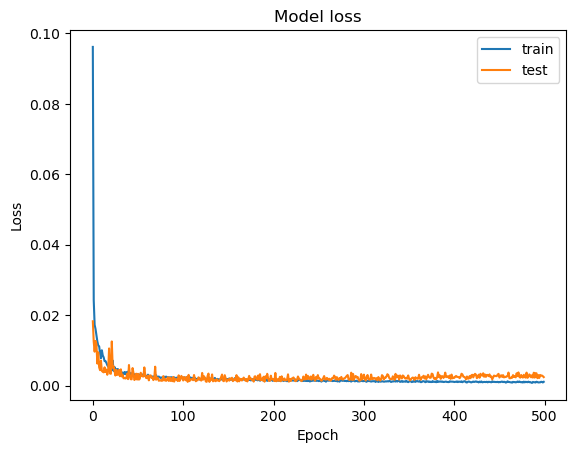

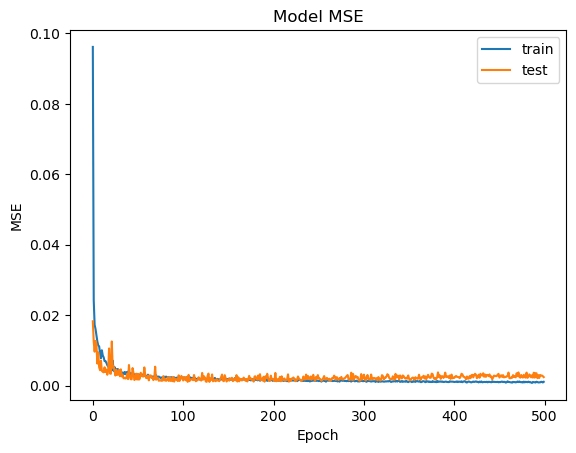

In [39]:
model = Sequential()  # 初始化
input = x.shape[1]
# 隐藏层128
model.add(Dense(128, input_shape=(input,)))  
model.add(Activation('relu'))
# Dropout层用于防止过拟合
model.add(Dropout(0.5))
# 隐藏层128
model.add(Dense(128))
model.add(Activation('relu'))

model.add(Dense(1))
model.add(Activation('linear'))  # 使用线性激活函数

# 使用高效的ADAM优化算法
rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
model.compile(loss='mean_squared_error', optimizer=rmsprop, metrics=['mean_squared_error'])

early_stopping = EarlyStopping(monitor='val_loss', patience=500, verbose=2)

# 训练
history = model.fit(x, y, epochs=500, batch_size=64, shuffle=False, verbose=2,
                   validation_data=(x_test, y_test), callbacks=[early_stopping])

# loss曲线
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# mse曲线
plt.plot(history.history['mean_squared_error'], label='train')
plt.plot(history.history['val_mean_squared_error'], label='test')
plt.title('Model MSE')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.show()



Epoch 1/500
5/5 - 1s - loss: 1.2509 - mean_squared_error: 1.2509 - val_loss: 0.0210 - val_mean_squared_error: 0.0210 - 722ms/epoch - 144ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6266 - mean_squared_error: 0.6266 - val_loss: 0.0729 - val_mean_squared_error: 0.0729 - 28ms/epoch - 6ms/step
Epoch 3/500
5/5 - 0s - loss: 0.4575 - mean_squared_error: 0.4575 - val_loss: 0.1048 - val_mean_squared_error: 0.1048 - 26ms/epoch - 5ms/step
Epoch 4/500
5/5 - 0s - loss: 0.3675 - mean_squared_error: 0.3675 - val_loss: 0.1090 - val_mean_squared_error: 0.1090 - 22ms/epoch - 4ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3047 - mean_squared_error: 0.3047 - val_loss: 0.1318 - val_mean_squared_error: 0.1318 - 30ms/epoch - 6ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3284 - mean_squared_error: 0.3284 - val_loss: 0.1233 - val_mean_squared_error: 0.1233 - 24ms/epoch - 5ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2395 - mean_squared_error: 0.2395 - val_loss: 0.1128 - val_mean_squared_error: 0.1128 - 26ms/epoch - 5ms/step
Epoch 8/50

Epoch 59/500
5/5 - 0s - loss: 0.0273 - mean_squared_error: 0.0273 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 38ms/epoch - 8ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0285 - mean_squared_error: 0.0285 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 24ms/epoch - 5ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0461 - mean_squared_error: 0.0461 - val_loss: 0.0227 - val_mean_squared_error: 0.0227 - 42ms/epoch - 8ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0333 - mean_squared_error: 0.0333 - val_loss: 0.0172 - val_mean_squared_error: 0.0172 - 33ms/epoch - 7ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0309 - mean_squared_error: 0.0309 - val_loss: 0.0088 - val_mean_squared_error: 0.0088 - 48ms/epoch - 10ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0280 - mean_squared_error: 0.0280 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 68ms/epoch - 14ms/step
Epoch 65/500
5/5 - 0s - loss: 0.0315 - mean_squared_error: 0.0315 - val_loss: 0.0064 - val_mean_squared_error: 0.0064 - 53ms/epoch - 11ms/step
Epo

Epoch 117/500
5/5 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 39ms/epoch - 8ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 42ms/epoch - 8ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0154 - mean_squared_error: 0.0154 - val_loss: 0.0062 - val_mean_squared_error: 0.0062 - 31ms/epoch - 6ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 30ms/epoch - 6ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0113 - val_mean_squared_error: 0.0113 - 31ms/epoch - 6ms/step
Epoch 122/500
5/5 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0075 - val_mean_squared_error: 0.0075 - 53ms/epoch - 11ms/step
Epoch 123/500
5/5 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0049 - val_mean_squared_error: 0.0049 - 53ms/epoch - 11ms/st

Epoch 175/500
5/5 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 30ms/epoch - 6ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 21ms/epoch - 4ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 59ms/epoch - 12ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0048 - val_mean_squared_error: 0.0048 - 32ms/epoch - 6ms/step
Epoch 179/500
5/5 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0042 - val_mean_squared_error: 0.0042 - 57ms/epoch - 11ms/step
Epoch 180/500
5/5 - 0s - loss: 0.0061 - mean_squared_error: 0.0061 - val_loss: 0.0068 - val_mean_squared_error: 0.0068 - 45ms/epoch - 9ms/step
Epoch 181/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0044 - val_mean_squared_error: 0.0044 - 43ms/epoch - 9ms/st

Epoch 233/500
5/5 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0051 - val_mean_squared_error: 0.0051 - 41ms/epoch - 8ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 37ms/epoch - 7ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 30ms/epoch - 6ms/step
Epoch 236/500
5/5 - 0s - loss: 0.0055 - mean_squared_error: 0.0055 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 36ms/epoch - 7ms/step
Epoch 237/500
5/5 - 0s - loss: 0.0057 - mean_squared_error: 0.0057 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 31ms/epoch - 6ms/step
Epoch 238/500
5/5 - 0s - loss: 0.0076 - mean_squared_error: 0.0076 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 24ms/epoch - 5ms/step
Epoch 239/500
5/5 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 30ms/epoch - 6ms/step

Epoch 291/500
5/5 - 0s - loss: 0.0063 - mean_squared_error: 0.0063 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 86ms/epoch - 17ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 84ms/epoch - 17ms/step
Epoch 293/500
5/5 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 78ms/epoch - 16ms/step
Epoch 294/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 67ms/epoch - 13ms/step
Epoch 295/500
5/5 - 0s - loss: 0.0052 - mean_squared_error: 0.0052 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 90ms/epoch - 18ms/step
Epoch 296/500
5/5 - 0s - loss: 0.0070 - mean_squared_error: 0.0070 - val_loss: 0.0059 - val_mean_squared_error: 0.0059 - 85ms/epoch - 17ms/step
Epoch 297/500
5/5 - 0s - loss: 0.0070 - mean_squared_error: 0.0070 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 50ms/epoch - 10

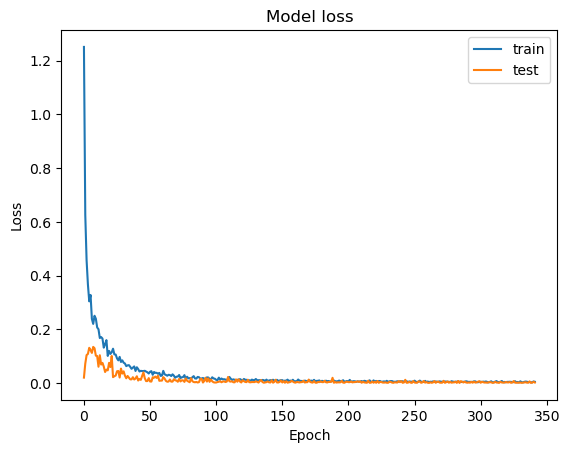

3/3 [==============================] - 0s 3ms/step
MSE: 0.00
R2: 0.88
Epoch 1/500
5/5 - 1s - loss: 1.1334 - mean_squared_error: 1.1334 - val_loss: 0.0318 - val_mean_squared_error: 0.0318 - 1s/epoch - 283ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6152 - mean_squared_error: 0.6152 - val_loss: 0.0535 - val_mean_squared_error: 0.0535 - 51ms/epoch - 10ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5584 - mean_squared_error: 0.5584 - val_loss: 0.0587 - val_mean_squared_error: 0.0587 - 47ms/epoch - 9ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4259 - mean_squared_error: 0.4259 - val_loss: 0.0616 - val_mean_squared_error: 0.0616 - 28ms/epoch - 6ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3976 - mean_squared_error: 0.3976 - val_loss: 0.0512 - val_mean_squared_error: 0.0512 - 30ms/epoch - 6ms/step
Epoch 6/500
5/5 - 0s - loss: 0.2984 - mean_squared_error: 0.2984 - val_loss: 0.0647 - val_mean_squared_error: 0.0647 - 52ms/epoch - 10ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2856 - mean_squared_error: 0.2856 - val_loss: 0.073

Epoch 59/500
5/5 - 0s - loss: 0.0285 - mean_squared_error: 0.0285 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 23ms/epoch - 5ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0316 - mean_squared_error: 0.0316 - val_loss: 0.0364 - val_mean_squared_error: 0.0364 - 37ms/epoch - 7ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0387 - mean_squared_error: 0.0387 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 49ms/epoch - 10ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0232 - mean_squared_error: 0.0232 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 47ms/epoch - 9ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0259 - mean_squared_error: 0.0259 - val_loss: 0.0138 - val_mean_squared_error: 0.0138 - 55ms/epoch - 11ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0356 - mean_squared_error: 0.0356 - val_loss: 0.0274 - val_mean_squared_error: 0.0274 - 62ms/epoch - 12ms/step
Epoch 65/500
5/5 - 0s - loss: 0.0289 - mean_squared_error: 0.0289 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 62ms/epoch - 12ms/step
Ep

Epoch 117/500
5/5 - 0s - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 27ms/epoch - 5ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 30ms/epoch - 6ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 22ms/epoch - 4ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0069 - val_mean_squared_error: 0.0069 - 25ms/epoch - 5ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0167 - mean_squared_error: 0.0167 - val_loss: 0.0042 - val_mean_squared_error: 0.0042 - 36ms/epoch - 7ms/step
Epoch 122/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 42ms/epoch - 8ms/step
Epoch 123/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 37ms/epoch - 7ms/step

Epoch 175/500
5/5 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 91ms/epoch - 18ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0055 - mean_squared_error: 0.0055 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 73ms/epoch - 15ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 72ms/epoch - 14ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 48ms/epoch - 10ms/step
Epoch 179/500
5/5 - 0s - loss: 0.0061 - mean_squared_error: 0.0061 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 32ms/epoch - 6ms/step
Epoch 180/500
5/5 - 0s - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 22ms/epoch - 4ms/step
Epoch 181/500
5/5 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0039 - val_mean_squared_error: 0.0039 - 65ms/epoch - 13ms

Epoch 233/500
5/5 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 41ms/epoch - 8ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 32ms/epoch - 6ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 38ms/epoch - 8ms/step
Epoch 236/500
5/5 - 0s - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 36ms/epoch - 7ms/step
Epoch 237/500
5/5 - 0s - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 24ms/epoch - 5ms/step
Epoch 238/500
5/5 - 0s - loss: 0.0061 - mean_squared_error: 0.0061 - val_loss: 0.0060 - val_mean_squared_error: 0.0060 - 30ms/epoch - 6ms/step
Epoch 239/500
5/5 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 24ms/epoch - 5ms/step

Epoch 291/500
5/5 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 69ms/epoch - 14ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 61ms/epoch - 12ms/step
Epoch 293/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 49ms/epoch - 10ms/step
Epoch 294/500
5/5 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 48ms/epoch - 10ms/step
Epoch 295/500
5/5 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0044 - val_mean_squared_error: 0.0044 - 36ms/epoch - 7ms/step
Epoch 296/500
5/5 - 0s - loss: 0.0061 - mean_squared_error: 0.0061 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 49ms/epoch - 10ms/step
Epoch 297/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 30ms/epoch - 6ms

5/5 - 0s - loss: 0.0064 - mean_squared_error: 0.0064 - val_loss: 0.0034 - val_mean_squared_error: 0.0034 - 31ms/epoch - 6ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0060 - val_mean_squared_error: 0.0060 - 42ms/epoch - 8ms/step
Epoch 350/500
5/5 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 31ms/epoch - 6ms/step
Epoch 351/500
5/5 - 0s - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 43ms/epoch - 9ms/step
Epoch 352/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0065 - val_mean_squared_error: 0.0065 - 49ms/epoch - 10ms/step
Epoch 353/500
5/5 - 0s - loss: 0.0064 - mean_squared_error: 0.0064 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 48ms/epoch - 10ms/step
Epoch 354/500
5/5 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 37ms/epoch - 7ms/step
Epoch 355/5

Epoch 406/500
5/5 - 0s - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0012 - val_mean_squared_error: 0.0012 - 68ms/epoch - 14ms/step
Epoch 407/500
5/5 - 0s - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 114ms/epoch - 23ms/step
Epoch 408/500
5/5 - 0s - loss: 0.0064 - mean_squared_error: 0.0064 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 91ms/epoch - 18ms/step
Epoch 409/500
5/5 - 0s - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 71ms/epoch - 14ms/step
Epoch 410/500
5/5 - 0s - loss: 0.0045 - mean_squared_error: 0.0045 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 56ms/epoch - 11ms/step
Epoch 411/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 43ms/epoch - 9ms/step
Epoch 412/500
5/5 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0034 - val_mean_squared_error: 0.0034 - 57ms/epoch - 11

Epoch 464/500
5/5 - 0s - loss: 0.0061 - mean_squared_error: 0.0061 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 30ms/epoch - 6ms/step
Epoch 465/500
5/5 - 0s - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0012 - val_mean_squared_error: 0.0012 - 43ms/epoch - 9ms/step
Epoch 466/500
5/5 - 0s - loss: 0.0027 - mean_squared_error: 0.0027 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 42ms/epoch - 8ms/step
Epoch 467/500
5/5 - 0s - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 24ms/epoch - 5ms/step
Epoch 468/500
5/5 - 0s - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 39ms/epoch - 8ms/step
Epoch 469/500
5/5 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0039 - val_mean_squared_error: 0.0039 - 38ms/epoch - 8ms/step
Epoch 470/500
5/5 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 41ms/epoch - 8ms/step

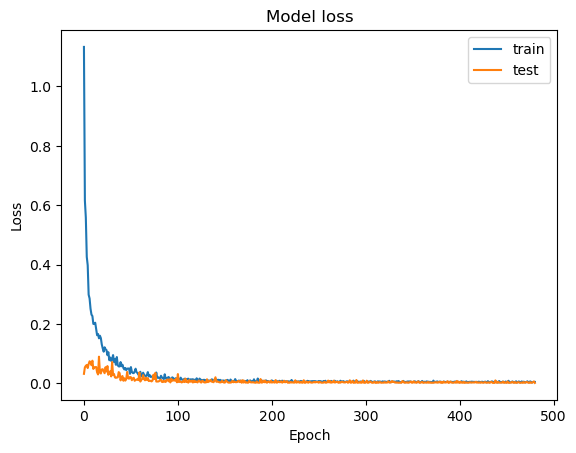

3/3 [==============================] - 0s 3ms/step
MSE: 0.00
R2: 0.95
Epoch 1/500
5/5 - 1s - loss: 1.4193 - mean_squared_error: 1.4193 - val_loss: 0.1503 - val_mean_squared_error: 0.1503 - 835ms/epoch - 167ms/step
Epoch 2/500
5/5 - 0s - loss: 0.7811 - mean_squared_error: 0.7811 - val_loss: 0.4944 - val_mean_squared_error: 0.4944 - 25ms/epoch - 5ms/step
Epoch 3/500
5/5 - 0s - loss: 0.6537 - mean_squared_error: 0.6537 - val_loss: 0.5531 - val_mean_squared_error: 0.5531 - 37ms/epoch - 7ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4781 - mean_squared_error: 0.4781 - val_loss: 0.5245 - val_mean_squared_error: 0.5245 - 31ms/epoch - 6ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4059 - mean_squared_error: 0.4059 - val_loss: 0.3340 - val_mean_squared_error: 0.3340 - 30ms/epoch - 6ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3550 - mean_squared_error: 0.3550 - val_loss: 0.1767 - val_mean_squared_error: 0.1767 - 32ms/epoch - 6ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2934 - mean_squared_error: 0.2934 - val_loss: 0.15

5/5 - 0s - loss: 0.0303 - mean_squared_error: 0.0303 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 64ms/epoch - 13ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0340 - mean_squared_error: 0.0340 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 54ms/epoch - 11ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0315 - mean_squared_error: 0.0315 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 30ms/epoch - 6ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0355 - mean_squared_error: 0.0355 - val_loss: 0.0458 - val_mean_squared_error: 0.0458 - 24ms/epoch - 5ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0434 - mean_squared_error: 0.0434 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 24ms/epoch - 5ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0355 - mean_squared_error: 0.0355 - val_loss: 0.0054 - val_mean_squared_error: 0.0054 - 18ms/epoch - 4ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0299 - mean_squared_error: 0.0299 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 24ms/epoch - 5ms/step
Epoch 65/500
5/5 

Epoch 116/500
5/5 - 0s - loss: 0.0116 - mean_squared_error: 0.0116 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - 53ms/epoch - 11ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0147 - mean_squared_error: 0.0147 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 50ms/epoch - 10ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 37ms/epoch - 7ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0140 - mean_squared_error: 0.0140 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 20ms/epoch - 4ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 30ms/epoch - 6ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0043 - val_mean_squared_error: 0.0043 - 30ms/epoch - 6ms/step
Epoch 122/500
5/5 - 0s - loss: 0.0146 - mean_squared_error: 0.0146 - val_loss: 0.0051 - val_mean_squared_error: 0.0051 - 31ms/epoch - 6ms/st

Epoch 174/500
5/5 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 25ms/epoch - 5ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0034 - val_mean_squared_error: 0.0034 - 23ms/epoch - 5ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0065 - mean_squared_error: 0.0065 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 24ms/epoch - 5ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 30ms/epoch - 6ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 39ms/epoch - 8ms/step
Epoch 179/500
5/5 - 0s - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0068 - val_mean_squared_error: 0.0068 - 55ms/epoch - 11ms/step
Epoch 180/500
5/5 - 0s - loss: 0.0068 - mean_squared_error: 0.0068 - val_loss: 0.0049 - val_mean_squared_error: 0.0049 - 35ms/epoch - 7ms/ste

Epoch 232/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 71ms/epoch - 14ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 90ms/epoch - 18ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0045 - mean_squared_error: 0.0045 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 76ms/epoch - 15ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 70ms/epoch - 14ms/step
Epoch 236/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 72ms/epoch - 14ms/step
Epoch 237/500
5/5 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - 42ms/epoch - 8ms/step
Epoch 238/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0014 - val_mean_squared_error: 0.0014 - 30ms/epoch - 6ms

Epoch 290/500
5/5 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 85ms/epoch - 17ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0049 - val_mean_squared_error: 0.0049 - 97ms/epoch - 19ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0063 - mean_squared_error: 0.0063 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 60ms/epoch - 12ms/step
Epoch 293/500
5/5 - 0s - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 61ms/epoch - 12ms/step
Epoch 294/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 85ms/epoch - 17ms/step
Epoch 295/500
5/5 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0036 - val_mean_squared_error: 0.0036 - 70ms/epoch - 14ms/step
Epoch 296/500
5/5 - 0s - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0013 - val_mean_squared_error: 0.0013 - 25ms/epoch - 5m

Epoch 348/500
5/5 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 25ms/epoch - 5ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0035 - val_mean_squared_error: 0.0035 - 24ms/epoch - 5ms/step
Epoch 350/500
5/5 - 0s - loss: 0.0061 - mean_squared_error: 0.0061 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 24ms/epoch - 5ms/step
Epoch 351/500
5/5 - 0s - loss: 0.0025 - mean_squared_error: 0.0025 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 30ms/epoch - 6ms/step
Epoch 352/500
5/5 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 36ms/epoch - 7ms/step
Epoch 353/500
5/5 - 0s - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 30ms/epoch - 6ms/step
Epoch 354/500
5/5 - 0s - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 25ms/epoch - 5ms/step

Epoch 406/500
5/5 - 0s - loss: 0.0028 - mean_squared_error: 0.0028 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 90ms/epoch - 18ms/step
Epoch 407/500
5/5 - 0s - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0014 - val_mean_squared_error: 0.0014 - 63ms/epoch - 13ms/step
Epoch 408/500
5/5 - 0s - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 52ms/epoch - 10ms/step
Epoch 409/500
5/5 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 31ms/epoch - 6ms/step
Epoch 410/500
5/5 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0011 - val_mean_squared_error: 0.0011 - 45ms/epoch - 9ms/step
Epoch 410: early stopping


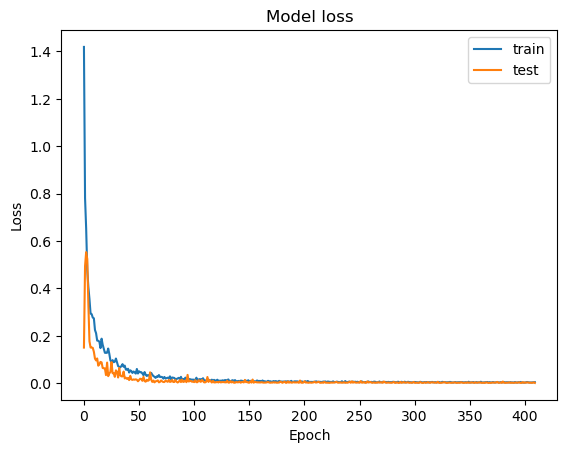

3/3 [==============================] - 0s 3ms/step
MSE: 0.00
R2: 0.95
Epoch 1/500
5/5 - 1s - loss: 1.6824 - mean_squared_error: 1.6824 - val_loss: 0.0269 - val_mean_squared_error: 0.0269 - 925ms/epoch - 185ms/step
Epoch 2/500
5/5 - 0s - loss: 0.8192 - mean_squared_error: 0.8192 - val_loss: 0.0350 - val_mean_squared_error: 0.0350 - 48ms/epoch - 10ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5626 - mean_squared_error: 0.5626 - val_loss: 0.0257 - val_mean_squared_error: 0.0257 - 34ms/epoch - 7ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4747 - mean_squared_error: 0.4747 - val_loss: 0.0425 - val_mean_squared_error: 0.0425 - 37ms/epoch - 7ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3739 - mean_squared_error: 0.3739 - val_loss: 0.0537 - val_mean_squared_error: 0.0537 - 32ms/epoch - 6ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3407 - mean_squared_error: 0.3407 - val_loss: 0.0583 - val_mean_squared_error: 0.0583 - 25ms/epoch - 5ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3203 - mean_squared_error: 0.3203 - val_loss: 0.0

Epoch 59/500
5/5 - 0s - loss: 0.0366 - mean_squared_error: 0.0366 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 27ms/epoch - 5ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0420 - mean_squared_error: 0.0420 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 33ms/epoch - 7ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0341 - mean_squared_error: 0.0341 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 51ms/epoch - 10ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0394 - mean_squared_error: 0.0394 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 49ms/epoch - 10ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0269 - mean_squared_error: 0.0269 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 49ms/epoch - 10ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0255 - mean_squared_error: 0.0255 - val_loss: 0.0199 - val_mean_squared_error: 0.0199 - 29ms/epoch - 6ms/step
Epoch 65/500
5/5 - 0s - loss: 0.0472 - mean_squared_error: 0.0472 - val_loss: 0.0244 - val_mean_squared_error: 0.0244 - 25ms/epoch - 5ms/step
Epo

Epoch 117/500
5/5 - 0s - loss: 0.0198 - mean_squared_error: 0.0198 - val_loss: 0.0158 - val_mean_squared_error: 0.0158 - 54ms/epoch - 11ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0157 - mean_squared_error: 0.0157 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 27ms/epoch - 5ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0195 - mean_squared_error: 0.0195 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 26ms/epoch - 5ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0123 - mean_squared_error: 0.0123 - val_loss: 0.0167 - val_mean_squared_error: 0.0167 - 20ms/epoch - 4ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0173 - mean_squared_error: 0.0173 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 49ms/epoch - 10ms/step
Epoch 122/500
5/5 - 0s - loss: 0.0187 - mean_squared_error: 0.0187 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 38ms/epoch - 8ms/step
Epoch 123/500
5/5 - 0s - loss: 0.0144 - mean_squared_error: 0.0144 - val_loss: 0.0069 - val_mean_squared_error: 0.0069 - 60ms/epoch - 12ms/s

Epoch 175/500
5/5 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 24ms/epoch - 5ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0173 - val_mean_squared_error: 0.0173 - 30ms/epoch - 6ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0045 - val_mean_squared_error: 0.0045 - 22ms/epoch - 4ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 22ms/epoch - 4ms/step
Epoch 179/500
5/5 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 25ms/epoch - 5ms/step
Epoch 180/500
5/5 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 53ms/epoch - 11ms/step
Epoch 181/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 41ms/epoch - 8ms/ste

Epoch 233/500
5/5 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 21ms/epoch - 4ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0045 - val_mean_squared_error: 0.0045 - 40ms/epoch - 8ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0039 - val_mean_squared_error: 0.0039 - 30ms/epoch - 6ms/step
Epoch 236/500
5/5 - 0s - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 27ms/epoch - 5ms/step
Epoch 237/500
5/5 - 0s - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 19ms/epoch - 4ms/step
Epoch 238/500
5/5 - 0s - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 35ms/epoch - 7ms/step
Epoch 239/500
5/5 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 22ms/epoch - 4ms/step

Epoch 291/500
5/5 - 0s - loss: 0.0056 - mean_squared_error: 0.0056 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 36ms/epoch - 7ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0056 - mean_squared_error: 0.0056 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 52ms/epoch - 10ms/step
Epoch 293/500
5/5 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0071 - val_mean_squared_error: 0.0071 - 48ms/epoch - 10ms/step
Epoch 294/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 32ms/epoch - 6ms/step
Epoch 295/500
5/5 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 59ms/epoch - 12ms/step
Epoch 296/500
5/5 - 0s - loss: 0.0072 - mean_squared_error: 0.0072 - val_loss: 0.0031 - val_mean_squared_error: 0.0031 - 48ms/epoch - 10ms/step
Epoch 297/500
5/5 - 0s - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 65ms/epoch - 13ms

Epoch 349/500
5/5 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 61ms/epoch - 12ms/step
Epoch 350/500
5/5 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 42ms/epoch - 8ms/step
Epoch 351/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 42ms/epoch - 8ms/step
Epoch 352/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0031 - val_mean_squared_error: 0.0031 - 36ms/epoch - 7ms/step
Epoch 353/500
5/5 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 25ms/epoch - 5ms/step
Epoch 354/500
5/5 - 0s - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 24ms/epoch - 5ms/step
Epoch 355/500
5/5 - 0s - loss: 0.0030 - mean_squared_error: 0.0030 - val_loss: 0.0010 - val_mean_squared_error: 0.0010 - 31ms/epoch - 6ms/ste

Epoch 407/500
5/5 - 0s - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 31ms/epoch - 6ms/step
Epoch 408/500
5/5 - 0s - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 53ms/epoch - 11ms/step
Epoch 409/500
5/5 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 37ms/epoch - 7ms/step
Epoch 410/500
5/5 - 0s - loss: 0.0030 - mean_squared_error: 0.0030 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 33ms/epoch - 7ms/step
Epoch 411/500
5/5 - 0s - loss: 0.0052 - mean_squared_error: 0.0052 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 35ms/epoch - 7ms/step
Epoch 412/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 26ms/epoch - 5ms/step
Epoch 413/500
5/5 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 25ms/epoch - 5ms/ste

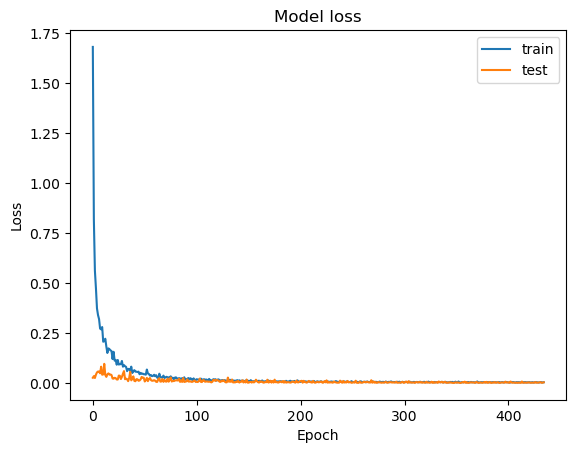

3/3 [==============================] - 0s 1ms/step
MSE: 0.00
R2: 0.83
Epoch 1/500
5/5 - 1s - loss: 1.5673 - mean_squared_error: 1.5673 - val_loss: 0.3347 - val_mean_squared_error: 0.3347 - 613ms/epoch - 123ms/step
Epoch 2/500
5/5 - 0s - loss: 0.7207 - mean_squared_error: 0.7207 - val_loss: 0.8224 - val_mean_squared_error: 0.8224 - 44ms/epoch - 9ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5960 - mean_squared_error: 0.5960 - val_loss: 0.8691 - val_mean_squared_error: 0.8691 - 32ms/epoch - 6ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4459 - mean_squared_error: 0.4459 - val_loss: 0.6207 - val_mean_squared_error: 0.6207 - 39ms/epoch - 8ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3676 - mean_squared_error: 0.3676 - val_loss: 0.3337 - val_mean_squared_error: 0.3337 - 43ms/epoch - 9ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3600 - mean_squared_error: 0.3600 - val_loss: 0.2640 - val_mean_squared_error: 0.2640 - 45ms/epoch - 9ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3079 - mean_squared_error: 0.3079 - val_loss: 0.19

Epoch 59/500
5/5 - 0s - loss: 0.0339 - mean_squared_error: 0.0339 - val_loss: 0.0222 - val_mean_squared_error: 0.0222 - 48ms/epoch - 10ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0296 - mean_squared_error: 0.0296 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 61ms/epoch - 12ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0318 - mean_squared_error: 0.0318 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - 63ms/epoch - 13ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0266 - mean_squared_error: 0.0266 - val_loss: 0.0159 - val_mean_squared_error: 0.0159 - 46ms/epoch - 9ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0354 - mean_squared_error: 0.0354 - val_loss: 0.0245 - val_mean_squared_error: 0.0245 - 42ms/epoch - 8ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0415 - mean_squared_error: 0.0415 - val_loss: 0.0169 - val_mean_squared_error: 0.0169 - 31ms/epoch - 6ms/step
Epoch 65/500
5/5 - 0s - loss: 0.0265 - mean_squared_error: 0.0265 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 32ms/epoch - 6ms/step
Epo

Epoch 117/500
5/5 - 0s - loss: 0.0153 - mean_squared_error: 0.0153 - val_loss: 0.0157 - val_mean_squared_error: 0.0157 - 16ms/epoch - 3ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0044 - val_mean_squared_error: 0.0044 - 47ms/epoch - 9ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0135 - mean_squared_error: 0.0135 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 59ms/epoch - 12ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0045 - val_mean_squared_error: 0.0045 - 47ms/epoch - 9ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0118 - mean_squared_error: 0.0118 - val_loss: 0.0034 - val_mean_squared_error: 0.0034 - 60ms/epoch - 12ms/step
Epoch 122/500
5/5 - 0s - loss: 0.0108 - mean_squared_error: 0.0108 - val_loss: 0.0032 - val_mean_squared_error: 0.0032 - 50ms/epoch - 10ms/step
Epoch 123/500
5/5 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - 34ms/epoch - 7ms/s

Epoch 175/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0073 - val_mean_squared_error: 0.0073 - 22ms/epoch - 4ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0059 - mean_squared_error: 0.0059 - val_loss: 0.0047 - val_mean_squared_error: 0.0047 - 23ms/epoch - 5ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 19ms/epoch - 4ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0076 - val_mean_squared_error: 0.0076 - 19ms/epoch - 4ms/step
Epoch 179/500
5/5 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0031 - val_mean_squared_error: 0.0031 - 35ms/epoch - 7ms/step
Epoch 180/500
5/5 - 0s - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 31ms/epoch - 6ms/step
Epoch 181/500
5/5 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - 34ms/epoch - 7ms/step

Epoch 233/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 31ms/epoch - 6ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 32ms/epoch - 6ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 31ms/epoch - 6ms/step
Epoch 236/500
5/5 - 0s - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0040 - val_mean_squared_error: 0.0040 - 27ms/epoch - 5ms/step
Epoch 237/500
5/5 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 40ms/epoch - 8ms/step
Epoch 238/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 56ms/epoch - 11ms/step
Epoch 239/500
5/5 - 0s - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0039 - val_mean_squared_error: 0.0039 - 26ms/epoch - 5ms/ste

Epoch 291/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 47ms/epoch - 9ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - 63ms/epoch - 13ms/step
Epoch 293/500
5/5 - 0s - loss: 0.0065 - mean_squared_error: 0.0065 - val_loss: 0.0041 - val_mean_squared_error: 0.0041 - 38ms/epoch - 8ms/step
Epoch 294/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 23ms/epoch - 5ms/step
Epoch 295/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 23ms/epoch - 5ms/step
Epoch 296/500
5/5 - 0s - loss: 0.0070 - mean_squared_error: 0.0070 - val_loss: 0.0072 - val_mean_squared_error: 0.0072 - 22ms/epoch - 4ms/step
Epoch 297/500
5/5 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0048 - val_mean_squared_error: 0.0048 - 26ms/epoch - 5ms/ste

Epoch 349/500
5/5 - 0s - loss: 0.0045 - mean_squared_error: 0.0045 - val_loss: 0.0035 - val_mean_squared_error: 0.0035 - 31ms/epoch - 6ms/step
Epoch 350/500
5/5 - 0s - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 16ms/epoch - 3ms/step
Epoch 351/500
5/5 - 0s - loss: 0.0052 - mean_squared_error: 0.0052 - val_loss: 0.0049 - val_mean_squared_error: 0.0049 - 32ms/epoch - 6ms/step
Epoch 352/500
5/5 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 24ms/epoch - 5ms/step
Epoch 353/500
5/5 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0050 - val_mean_squared_error: 0.0050 - 33ms/epoch - 7ms/step
Epoch 354/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0014 - val_mean_squared_error: 0.0014 - 56ms/epoch - 11ms/step
Epoch 355/500
5/5 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 38ms/epoch - 8ms/ste

Epoch 407/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 24ms/epoch - 5ms/step
Epoch 408/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 24ms/epoch - 5ms/step
Epoch 409/500
5/5 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0035 - val_mean_squared_error: 0.0035 - 24ms/epoch - 5ms/step
Epoch 410/500
5/5 - 0s - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 24ms/epoch - 5ms/step
Epoch 411/500
5/5 - 0s - loss: 0.0030 - mean_squared_error: 0.0030 - val_loss: 0.0040 - val_mean_squared_error: 0.0040 - 18ms/epoch - 4ms/step
Epoch 412/500
5/5 - 0s - loss: 0.0057 - mean_squared_error: 0.0057 - val_loss: 0.0014 - val_mean_squared_error: 0.0014 - 25ms/epoch - 5ms/step
Epoch 413/500
5/5 - 0s - loss: 0.0028 - mean_squared_error: 0.0028 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 49ms/epoch - 10ms/ste

Epoch 465/500
5/5 - 0s - loss: 0.0025 - mean_squared_error: 0.0025 - val_loss: 0.0012 - val_mean_squared_error: 0.0012 - 24ms/epoch - 5ms/step
Epoch 466/500
5/5 - 0s - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0043 - val_mean_squared_error: 0.0043 - 22ms/epoch - 4ms/step
Epoch 467/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 12ms/epoch - 2ms/step
Epoch 468/500
5/5 - 0s - loss: 0.0024 - mean_squared_error: 0.0024 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 16ms/epoch - 3ms/step
Epoch 469/500
5/5 - 0s - loss: 0.0029 - mean_squared_error: 0.0029 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 32ms/epoch - 6ms/step
Epoch 470/500
5/5 - 0s - loss: 0.0061 - mean_squared_error: 0.0061 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 31ms/epoch - 6ms/step
Epoch 471/500
5/5 - 0s - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0013 - val_mean_squared_error: 0.0013 - 29ms/epoch - 6ms/step

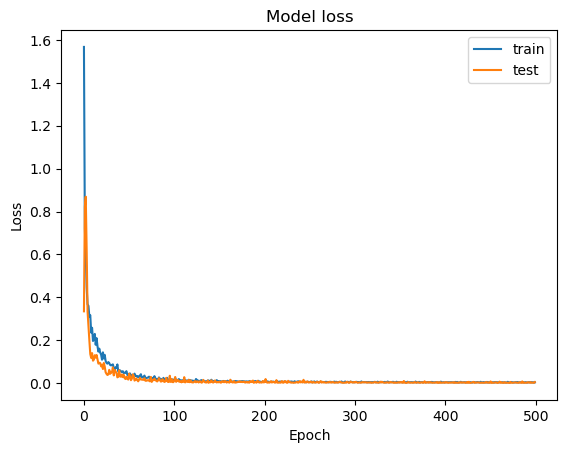

3/3 [==============================] - 0s 3ms/step
MSE: 0.00
R2: 0.79
Epoch 1/500
5/5 - 1s - loss: 1.2314 - mean_squared_error: 1.2314 - val_loss: 0.3477 - val_mean_squared_error: 0.3477 - 689ms/epoch - 138ms/step
Epoch 2/500
5/5 - 0s - loss: 0.8439 - mean_squared_error: 0.8439 - val_loss: 0.4708 - val_mean_squared_error: 0.4708 - 35ms/epoch - 7ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5066 - mean_squared_error: 0.5066 - val_loss: 0.4776 - val_mean_squared_error: 0.4776 - 28ms/epoch - 6ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4317 - mean_squared_error: 0.4317 - val_loss: 0.3580 - val_mean_squared_error: 0.3580 - 16ms/epoch - 3ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3491 - mean_squared_error: 0.3491 - val_loss: 0.2831 - val_mean_squared_error: 0.2831 - 18ms/epoch - 4ms/step
Epoch 6/500
5/5 - 0s - loss: 0.2969 - mean_squared_error: 0.2969 - val_loss: 0.1711 - val_mean_squared_error: 0.1711 - 30ms/epoch - 6ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2730 - mean_squared_error: 0.2730 - val_loss: 0.15

Epoch 54/500
5/5 - 0s - loss: 0.0288 - mean_squared_error: 0.0288 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 11ms/epoch - 2ms/step
Epoch 55/500
5/5 - 0s - loss: 0.0285 - mean_squared_error: 0.0285 - val_loss: 0.0200 - val_mean_squared_error: 0.0200 - 35ms/epoch - 7ms/step
Epoch 56/500
5/5 - 0s - loss: 0.0275 - mean_squared_error: 0.0275 - val_loss: 0.0072 - val_mean_squared_error: 0.0072 - 25ms/epoch - 5ms/step
Epoch 57/500
5/5 - 0s - loss: 0.0261 - mean_squared_error: 0.0261 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 21ms/epoch - 4ms/step
Epoch 58/500
5/5 - 0s - loss: 0.0279 - mean_squared_error: 0.0279 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 39ms/epoch - 8ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0238 - mean_squared_error: 0.0238 - val_loss: 0.0135 - val_mean_squared_error: 0.0135 - 25ms/epoch - 5ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0283 - mean_squared_error: 0.0283 - val_loss: 0.0180 - val_mean_squared_error: 0.0180 - 23ms/epoch - 5ms/step
Epoch 

Epoch 112/500
5/5 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 24ms/epoch - 5ms/step
Epoch 113/500
5/5 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 34ms/epoch - 7ms/step
Epoch 114/500
5/5 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0031 - val_mean_squared_error: 0.0031 - 33ms/epoch - 7ms/step
Epoch 115/500
5/5 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 31ms/epoch - 6ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0036 - val_mean_squared_error: 0.0036 - 27ms/epoch - 5ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0182 - mean_squared_error: 0.0182 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - 32ms/epoch - 6ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0035 - val_mean_squared_error: 0.0035 - 17ms/epoch - 3ms/step

Epoch 170/500
5/5 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 47ms/epoch - 9ms/step
Epoch 171/500
5/5 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0035 - val_mean_squared_error: 0.0035 - 12ms/epoch - 2ms/step
Epoch 172/500
5/5 - 0s - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 36ms/epoch - 7ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0044 - val_mean_squared_error: 0.0044 - 27ms/epoch - 5ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 16ms/epoch - 3ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 16ms/epoch - 3ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 16ms/epoch - 3ms/step

Epoch 228/500
5/5 - 0s - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 49ms/epoch - 10ms/step
Epoch 229/500
5/5 - 0s - loss: 0.0063 - mean_squared_error: 0.0063 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 39ms/epoch - 8ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 41ms/epoch - 8ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 62ms/epoch - 12ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0032 - val_mean_squared_error: 0.0032 - 47ms/epoch - 9ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 47ms/epoch - 9ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 27ms/epoch - 5ms/st

Epoch 286/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0046 - val_mean_squared_error: 0.0046 - 35ms/epoch - 7ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0051 - val_mean_squared_error: 0.0051 - 41ms/epoch - 8ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 37ms/epoch - 7ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0013 - val_mean_squared_error: 0.0013 - 41ms/epoch - 8ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0047 - val_mean_squared_error: 0.0047 - 50ms/epoch - 10ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0068 - mean_squared_error: 0.0068 - val_loss: 0.0040 - val_mean_squared_error: 0.0040 - 55ms/epoch - 11ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0041 - val_mean_squared_error: 0.0041 - 40ms/epoch - 8ms/st

Epoch 344/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - 30ms/epoch - 6ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 32ms/epoch - 6ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 48ms/epoch - 10ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 48ms/epoch - 10ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0042 - val_mean_squared_error: 0.0042 - 63ms/epoch - 13ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 47ms/epoch - 9ms/step
Epoch 350/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - 47ms/epoch - 9ms/s

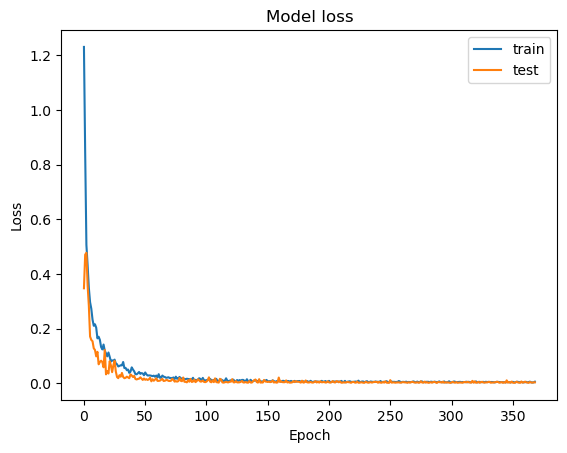

3/3 [==============================] - 0s 0s/step
MSE: 0.00
R2: 0.86
Epoch 1/500
5/5 - 1s - loss: 1.6288 - mean_squared_error: 1.6288 - val_loss: 0.0748 - val_mean_squared_error: 0.0748 - 622ms/epoch - 124ms/step
Epoch 2/500
5/5 - 0s - loss: 0.7134 - mean_squared_error: 0.7134 - val_loss: 0.0574 - val_mean_squared_error: 0.0574 - 47ms/epoch - 9ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5708 - mean_squared_error: 0.5708 - val_loss: 0.0226 - val_mean_squared_error: 0.0226 - 31ms/epoch - 6ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4296 - mean_squared_error: 0.4296 - val_loss: 0.0275 - val_mean_squared_error: 0.0275 - 16ms/epoch - 3ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3647 - mean_squared_error: 0.3647 - val_loss: 0.0557 - val_mean_squared_error: 0.0557 - 32ms/epoch - 6ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3183 - mean_squared_error: 0.3183 - val_loss: 0.0458 - val_mean_squared_error: 0.0458 - 16ms/epoch - 3ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2991 - mean_squared_error: 0.2991 - val_loss: 0.060

Epoch 54/500
5/5 - 0s - loss: 0.0356 - mean_squared_error: 0.0356 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 31ms/epoch - 6ms/step
Epoch 55/500
5/5 - 0s - loss: 0.0421 - mean_squared_error: 0.0421 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 32ms/epoch - 6ms/step
Epoch 56/500
5/5 - 0s - loss: 0.0334 - mean_squared_error: 0.0334 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 31ms/epoch - 6ms/step
Epoch 57/500
5/5 - 0s - loss: 0.0425 - mean_squared_error: 0.0425 - val_loss: 0.0181 - val_mean_squared_error: 0.0181 - 32ms/epoch - 6ms/step
Epoch 58/500
5/5 - 0s - loss: 0.0358 - mean_squared_error: 0.0358 - val_loss: 0.0205 - val_mean_squared_error: 0.0205 - 31ms/epoch - 6ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0374 - mean_squared_error: 0.0374 - val_loss: 0.0252 - val_mean_squared_error: 0.0252 - 31ms/epoch - 6ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0374 - mean_squared_error: 0.0374 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 16ms/epoch - 3ms/step
Epoch 

Epoch 112/500
5/5 - 0s - loss: 0.0172 - mean_squared_error: 0.0172 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - 56ms/epoch - 11ms/step
Epoch 113/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0036 - val_mean_squared_error: 0.0036 - 27ms/epoch - 5ms/step
Epoch 114/500
5/5 - 0s - loss: 0.0209 - mean_squared_error: 0.0209 - val_loss: 0.0053 - val_mean_squared_error: 0.0053 - 44ms/epoch - 9ms/step
Epoch 115/500
5/5 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 50ms/epoch - 10ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0223 - mean_squared_error: 0.0223 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - 59ms/epoch - 12ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 56ms/epoch - 11ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0108 - mean_squared_error: 0.0108 - val_loss: 0.0060 - val_mean_squared_error: 0.0060 - 49ms/epoch - 10ms

Epoch 170/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0035 - val_mean_squared_error: 0.0035 - 47ms/epoch - 9ms/step
Epoch 171/500
5/5 - 0s - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 31ms/epoch - 6ms/step
Epoch 172/500
5/5 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0069 - val_mean_squared_error: 0.0069 - 44ms/epoch - 9ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0076 - mean_squared_error: 0.0076 - val_loss: 0.0068 - val_mean_squared_error: 0.0068 - 47ms/epoch - 9ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 49ms/epoch - 10ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 14ms/epoch - 3ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 32ms/epoch - 6ms/ste

Epoch 228/500
5/5 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0076 - val_mean_squared_error: 0.0076 - 16ms/epoch - 3ms/step
Epoch 229/500
5/5 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 31ms/epoch - 6ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 47ms/epoch - 9ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 49ms/epoch - 10ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - 46ms/epoch - 9ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0072 - mean_squared_error: 0.0072 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 31ms/epoch - 6ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0064 - mean_squared_error: 0.0064 - val_loss: 0.0011 - val_mean_squared_error: 0.0011 - 49ms/epoch - 10ms/st

Epoch 286/500
5/5 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 16ms/epoch - 3ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0032 - val_mean_squared_error: 0.0032 - 16ms/epoch - 3ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0014 - val_mean_squared_error: 0.0014 - 16ms/epoch - 3ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 31ms/epoch - 6ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0065 - val_mean_squared_error: 0.0065 - 33ms/epoch - 7ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 25ms/epoch - 5ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 28ms/epoch - 6ms/step

Epoch 344/500
5/5 - 0s - loss: 0.0050 - mean_squared_error: 0.0050 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 31ms/epoch - 6ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 16ms/epoch - 3ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 32ms/epoch - 6ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0042 - val_mean_squared_error: 0.0042 - 16ms/epoch - 3ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 32ms/epoch - 6ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0034 - val_mean_squared_error: 0.0034 - 15ms/epoch - 3ms/step
Epoch 350/500
5/5 - 0s - loss: 0.0030 - mean_squared_error: 0.0030 - val_loss: 0.0039 - val_mean_squared_error: 0.0039 - 18ms/epoch - 4ms/step

Epoch 402/500
5/5 - 0s - loss: 0.0025 - mean_squared_error: 0.0025 - val_loss: 0.0028 - val_mean_squared_error: 0.0028 - 50ms/epoch - 10ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0031 - val_mean_squared_error: 0.0031 - 61ms/epoch - 12ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 47ms/epoch - 9ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 51ms/epoch - 10ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0012 - val_mean_squared_error: 0.0012 - 50ms/epoch - 10ms/step
Epoch 407/500
5/5 - 0s - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 50ms/epoch - 10ms/step
Epoch 408/500
5/5 - 0s - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 45ms/epoch - 9ms

5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0015 - val_mean_squared_error: 0.0015 - 43ms/epoch - 9ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 37ms/epoch - 7ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 48ms/epoch - 10ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0034 - val_mean_squared_error: 0.0034 - 47ms/epoch - 9ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 26ms/epoch - 5ms/step
Epoch 464/500
5/5 - 0s - loss: 0.0023 - mean_squared_error: 0.0023 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 27ms/epoch - 5ms/step
Epoch 465/500
5/5 - 0s - loss: 0.0028 - mean_squared_error: 0.0028 - val_loss: 0.0011 - val_mean_squared_error: 0.0011 - 34ms/epoch - 7ms/step
Epoch 466/50

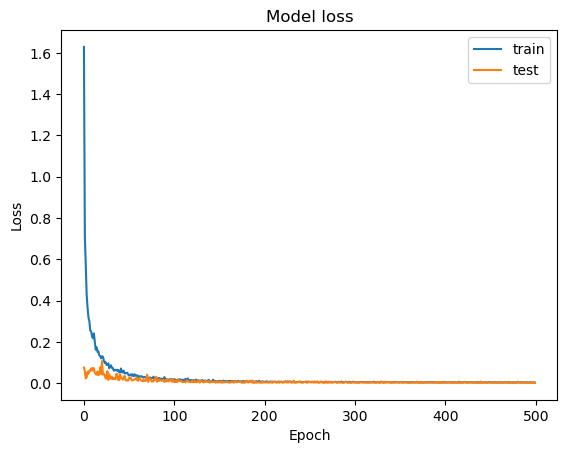

3/3 [==============================] - 0s 1ms/step
MSE: 0.00
R2: 0.95
Epoch 1/500
5/5 - 1s - loss: 1.5571 - mean_squared_error: 1.5571 - val_loss: 0.3394 - val_mean_squared_error: 0.3394 - 928ms/epoch - 186ms/step
Epoch 2/500
5/5 - 0s - loss: 0.8157 - mean_squared_error: 0.8157 - val_loss: 0.3544 - val_mean_squared_error: 0.3544 - 63ms/epoch - 13ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5281 - mean_squared_error: 0.5281 - val_loss: 0.3400 - val_mean_squared_error: 0.3400 - 31ms/epoch - 6ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4166 - mean_squared_error: 0.4166 - val_loss: 0.2429 - val_mean_squared_error: 0.2429 - 32ms/epoch - 6ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3723 - mean_squared_error: 0.3723 - val_loss: 0.1769 - val_mean_squared_error: 0.1769 - 16ms/epoch - 3ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3729 - mean_squared_error: 0.3729 - val_loss: 0.1402 - val_mean_squared_error: 0.1402 - 31ms/epoch - 6ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2884 - mean_squared_error: 0.2884 - val_loss: 0.1

Epoch 59/500
5/5 - 0s - loss: 0.0359 - mean_squared_error: 0.0359 - val_loss: 0.0204 - val_mean_squared_error: 0.0204 - 27ms/epoch - 5ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0402 - mean_squared_error: 0.0402 - val_loss: 0.0143 - val_mean_squared_error: 0.0143 - 36ms/epoch - 7ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0455 - mean_squared_error: 0.0455 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 40ms/epoch - 8ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0299 - mean_squared_error: 0.0299 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 61ms/epoch - 12ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0343 - mean_squared_error: 0.0343 - val_loss: 0.0201 - val_mean_squared_error: 0.0201 - 36ms/epoch - 7ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0420 - mean_squared_error: 0.0420 - val_loss: 0.0181 - val_mean_squared_error: 0.0181 - 31ms/epoch - 6ms/step
Epoch 65/500
5/5 - 0s - loss: 0.0356 - mean_squared_error: 0.0356 - val_loss: 0.0154 - val_mean_squared_error: 0.0154 - 26ms/epoch - 5ms/step
Epoch

Epoch 117/500
5/5 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 27ms/epoch - 5ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 22ms/epoch - 4ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0181 - mean_squared_error: 0.0181 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 23ms/epoch - 5ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 32ms/epoch - 6ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 27ms/epoch - 5ms/step
Epoch 122/500
5/5 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - 25ms/epoch - 5ms/step
Epoch 123/500
5/5 - 0s - loss: 0.0137 - mean_squared_error: 0.0137 - val_loss: 0.0075 - val_mean_squared_error: 0.0075 - 25ms/epoch - 5ms/step

Epoch 175/500
5/5 - 0s - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 30ms/epoch - 6ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 36ms/epoch - 7ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 43ms/epoch - 9ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0044 - val_mean_squared_error: 0.0044 - 54ms/epoch - 11ms/step
Epoch 179/500
5/5 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0060 - val_mean_squared_error: 0.0060 - 49ms/epoch - 10ms/step
Epoch 180/500
5/5 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 25ms/epoch - 5ms/step
Epoch 181/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0035 - val_mean_squared_error: 0.0035 - 24ms/epoch - 5ms/st

Epoch 233/500
5/5 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0048 - val_mean_squared_error: 0.0048 - 43ms/epoch - 9ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 48ms/epoch - 10ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 43ms/epoch - 9ms/step
Epoch 236/500
5/5 - 0s - loss: 0.0068 - mean_squared_error: 0.0068 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 62ms/epoch - 12ms/step
Epoch 237/500
5/5 - 0s - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - 38ms/epoch - 8ms/step
Epoch 238/500
5/5 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0046 - val_mean_squared_error: 0.0046 - 31ms/epoch - 6ms/step
Epoch 239/500
5/5 - 0s - loss: 0.0059 - mean_squared_error: 0.0059 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 38ms/epoch - 8ms/st

Epoch 291/500
5/5 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0026 - val_mean_squared_error: 0.0026 - 45ms/epoch - 9ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 43ms/epoch - 9ms/step
Epoch 293/500
5/5 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0036 - val_mean_squared_error: 0.0036 - 48ms/epoch - 10ms/step
Epoch 294/500
5/5 - 0s - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - 16ms/epoch - 3ms/step
Epoch 295/500
5/5 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0054 - val_mean_squared_error: 0.0054 - 31ms/epoch - 6ms/step
Epoch 296/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0031 - val_mean_squared_error: 0.0031 - 38ms/epoch - 8ms/step
Epoch 297/500
5/5 - 0s - loss: 0.0055 - mean_squared_error: 0.0055 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 25ms/epoch - 5ms/ste

Epoch 349/500
5/5 - 0s - loss: 0.0052 - mean_squared_error: 0.0052 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - 30ms/epoch - 6ms/step
Epoch 350/500
5/5 - 0s - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0024 - val_mean_squared_error: 0.0024 - 50ms/epoch - 10ms/step
Epoch 351/500
5/5 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 34ms/epoch - 7ms/step
Epoch 352/500
5/5 - 0s - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 47ms/epoch - 9ms/step
Epoch 353/500
5/5 - 0s - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 48ms/epoch - 10ms/step
Epoch 354/500
5/5 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0031 - val_mean_squared_error: 0.0031 - 63ms/epoch - 13ms/step
Epoch 355/500
5/5 - 0s - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0043 - val_mean_squared_error: 0.0043 - 47ms/epoch - 9ms/s

Epoch 407/500
5/5 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0046 - val_mean_squared_error: 0.0046 - 17ms/epoch - 3ms/step
Epoch 408/500
5/5 - 0s - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0010 - val_mean_squared_error: 0.0010 - 33ms/epoch - 7ms/step
Epoch 409/500
5/5 - 0s - loss: 0.0030 - mean_squared_error: 0.0030 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 24ms/epoch - 5ms/step
Epoch 410/500
5/5 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0012 - val_mean_squared_error: 0.0012 - 23ms/epoch - 5ms/step
Epoch 411/500
5/5 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - 24ms/epoch - 5ms/step
Epoch 412/500
5/5 - 0s - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0014 - val_mean_squared_error: 0.0014 - 16ms/epoch - 3ms/step
Epoch 413/500
5/5 - 0s - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0016 - val_mean_squared_error: 0.0016 - 19ms/epoch - 4ms/step

Epoch 465/500
5/5 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 58ms/epoch - 12ms/step
Epoch 466/500
5/5 - 0s - loss: 0.0025 - mean_squared_error: 0.0025 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 60ms/epoch - 12ms/step
Epoch 467/500
5/5 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 46ms/epoch - 9ms/step
Epoch 468/500
5/5 - 0s - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 62ms/epoch - 12ms/step
Epoch 469/500
5/5 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0043 - val_mean_squared_error: 0.0043 - 62ms/epoch - 12ms/step
Epoch 470/500
5/5 - 0s - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0014 - val_mean_squared_error: 0.0014 - 38ms/epoch - 8ms/step
Epoch 471/500
5/5 - 0s - loss: 0.0027 - mean_squared_error: 0.0027 - val_loss: 0.0031 - val_mean_squared_error: 0.0031 - 36ms/epoch - 7ms/

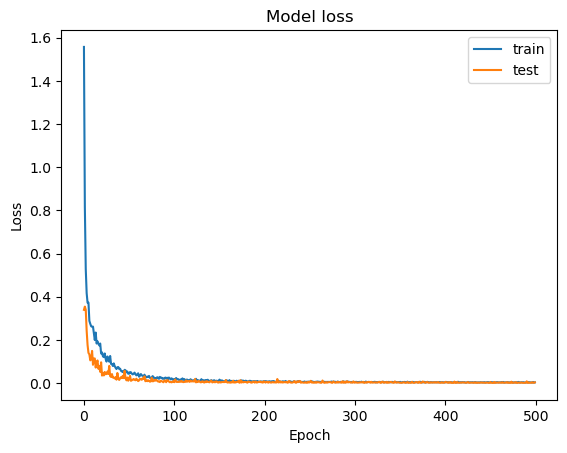

3/3 [==============================] - 0s 0s/step
MSE: 0.00
R2: 0.85
Epoch 1/500
5/5 - 1s - loss: 1.5755 - mean_squared_error: 1.5755 - val_loss: 0.0354 - val_mean_squared_error: 0.0354 - 611ms/epoch - 122ms/step
Epoch 2/500
5/5 - 0s - loss: 0.8478 - mean_squared_error: 0.8478 - val_loss: 0.0749 - val_mean_squared_error: 0.0749 - 30ms/epoch - 6ms/step
Epoch 3/500
5/5 - 0s - loss: 0.6007 - mean_squared_error: 0.6007 - val_loss: 0.0582 - val_mean_squared_error: 0.0582 - 31ms/epoch - 6ms/step
Epoch 4/500
5/5 - 0s - loss: 0.3982 - mean_squared_error: 0.3982 - val_loss: 0.0715 - val_mean_squared_error: 0.0715 - 16ms/epoch - 3ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4162 - mean_squared_error: 0.4162 - val_loss: 0.0509 - val_mean_squared_error: 0.0509 - 34ms/epoch - 7ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3010 - mean_squared_error: 0.3010 - val_loss: 0.1003 - val_mean_squared_error: 0.1003 - 20ms/epoch - 4ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2527 - mean_squared_error: 0.2527 - val_loss: 0.060

Epoch 59/500
5/5 - 0s - loss: 0.0348 - mean_squared_error: 0.0348 - val_loss: 0.0239 - val_mean_squared_error: 0.0239 - 37ms/epoch - 7ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0333 - mean_squared_error: 0.0333 - val_loss: 0.0255 - val_mean_squared_error: 0.0255 - 32ms/epoch - 6ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0302 - mean_squared_error: 0.0302 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 32ms/epoch - 6ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0324 - mean_squared_error: 0.0324 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 32ms/epoch - 6ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0232 - mean_squared_error: 0.0232 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 31ms/epoch - 6ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0305 - mean_squared_error: 0.0305 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 27ms/epoch - 5ms/step
Epoch 65/500
5/5 - 0s - loss: 0.0269 - mean_squared_error: 0.0269 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - 19ms/epoch - 4ms/step
Epoch 

Epoch 117/500
5/5 - 0s - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0041 - val_mean_squared_error: 0.0041 - 32ms/epoch - 6ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0052 - val_mean_squared_error: 0.0052 - 47ms/epoch - 9ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0034 - val_mean_squared_error: 0.0034 - 60ms/epoch - 12ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 35ms/epoch - 7ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0181 - mean_squared_error: 0.0181 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 32ms/epoch - 6ms/step
Epoch 122/500
5/5 - 0s - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 33ms/epoch - 7ms/step
Epoch 123/500
5/5 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 40ms/epoch - 8ms/ste

Epoch 175/500
5/5 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0047 - val_mean_squared_error: 0.0047 - 15ms/epoch - 3ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 32ms/epoch - 6ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - 15ms/epoch - 3ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0062 - val_mean_squared_error: 0.0062 - 32ms/epoch - 6ms/step
Epoch 179/500
5/5 - 0s - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0029 - val_mean_squared_error: 0.0029 - 15ms/epoch - 3ms/step
Epoch 180/500
5/5 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0068 - val_mean_squared_error: 0.0068 - 32ms/epoch - 6ms/step
Epoch 181/500
5/5 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0044 - val_mean_squared_error: 0.0044 - 32ms/epoch - 6ms/step

Epoch 233/500
5/5 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 17ms/epoch - 3ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 31ms/epoch - 6ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - 15ms/epoch - 3ms/step
Epoch 236/500
5/5 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0045 - val_mean_squared_error: 0.0045 - 31ms/epoch - 6ms/step
Epoch 237/500
5/5 - 0s - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0033 - val_mean_squared_error: 0.0033 - 23ms/epoch - 5ms/step
Epoch 238/500
5/5 - 0s - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - 13ms/epoch - 3ms/step
Epoch 239/500
5/5 - 0s - loss: 0.0070 - mean_squared_error: 0.0070 - val_loss: 0.0052 - val_mean_squared_error: 0.0052 - 16ms/epoch - 3ms/step

Epoch 291/500
5/5 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - 16ms/epoch - 3ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 31ms/epoch - 6ms/step
Epoch 293/500
5/5 - 0s - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0078 - val_mean_squared_error: 0.0078 - 32ms/epoch - 6ms/step
Epoch 294/500
5/5 - 0s - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0032 - val_mean_squared_error: 0.0032 - 47ms/epoch - 9ms/step
Epoch 295/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 31ms/epoch - 6ms/step
Epoch 296/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 32ms/epoch - 6ms/step
Epoch 297/500
5/5 - 0s - loss: 0.0072 - mean_squared_error: 0.0072 - val_loss: 0.0040 - val_mean_squared_error: 0.0040 - 16ms/epoch - 3ms/step

Epoch 349/500
5/5 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 23ms/epoch - 5ms/step
Epoch 350/500
5/5 - 0s - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0050 - val_mean_squared_error: 0.0050 - 24ms/epoch - 5ms/step
Epoch 350: early stopping


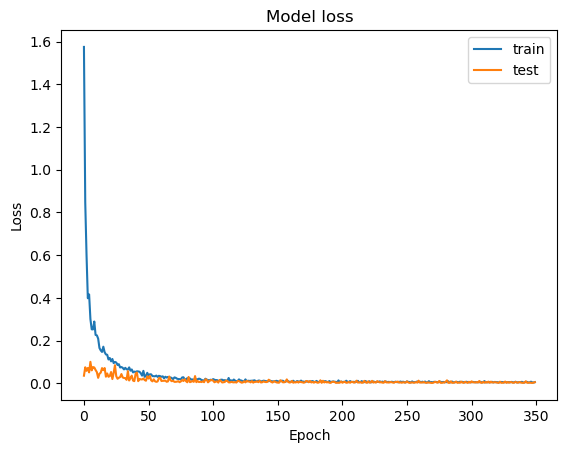

3/3 [==============================] - 0s 2ms/step
MSE: 0.00
R2: 0.79
Epoch 1/500
5/5 - 1s - loss: 1.2726 - mean_squared_error: 1.2726 - val_loss: 0.6985 - val_mean_squared_error: 0.6985 - 570ms/epoch - 114ms/step
Epoch 2/500
5/5 - 0s - loss: 0.7304 - mean_squared_error: 0.7304 - val_loss: 1.0887 - val_mean_squared_error: 1.0887 - 63ms/epoch - 13ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5900 - mean_squared_error: 0.5900 - val_loss: 0.9136 - val_mean_squared_error: 0.9136 - 47ms/epoch - 9ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4531 - mean_squared_error: 0.4531 - val_loss: 0.5477 - val_mean_squared_error: 0.5477 - 47ms/epoch - 9ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4068 - mean_squared_error: 0.4068 - val_loss: 0.3523 - val_mean_squared_error: 0.3523 - 40ms/epoch - 8ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3177 - mean_squared_error: 0.3177 - val_loss: 0.2413 - val_mean_squared_error: 0.2413 - 16ms/epoch - 3ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2978 - mean_squared_error: 0.2978 - val_loss: 0.1

Epoch 59/500
5/5 - 0s - loss: 0.0339 - mean_squared_error: 0.0339 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 17ms/epoch - 3ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0403 - mean_squared_error: 0.0403 - val_loss: 0.0185 - val_mean_squared_error: 0.0185 - 15ms/epoch - 3ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0281 - mean_squared_error: 0.0281 - val_loss: 0.0158 - val_mean_squared_error: 0.0158 - 31ms/epoch - 6ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0342 - mean_squared_error: 0.0342 - val_loss: 0.0171 - val_mean_squared_error: 0.0171 - 16ms/epoch - 3ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0291 - mean_squared_error: 0.0291 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 47ms/epoch - 9ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0278 - mean_squared_error: 0.0278 - val_loss: 0.0324 - val_mean_squared_error: 0.0324 - 47ms/epoch - 9ms/step
Epoch 65/500
5/5 - 0s - loss: 0.0365 - mean_squared_error: 0.0365 - val_loss: 0.0153 - val_mean_squared_error: 0.0153 - 59ms/epoch - 12ms/step
Epoch

Epoch 117/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0039 - val_mean_squared_error: 0.0039 - 31ms/epoch - 6ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 31ms/epoch - 6ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0182 - mean_squared_error: 0.0182 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 27ms/epoch - 5ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0046 - val_mean_squared_error: 0.0046 - 30ms/epoch - 6ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0112 - val_mean_squared_error: 0.0112 - 35ms/epoch - 7ms/step
Epoch 122/500
5/5 - 0s - loss: 0.0194 - mean_squared_error: 0.0194 - val_loss: 0.0031 - val_mean_squared_error: 0.0031 - 34ms/epoch - 7ms/step
Epoch 123/500
5/5 - 0s - loss: 0.0076 - mean_squared_error: 0.0076 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 29ms/epoch - 6ms/step

Epoch 175/500
5/5 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0018 - val_mean_squared_error: 0.0018 - 17ms/epoch - 3ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 18ms/epoch - 4ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 30ms/epoch - 6ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - 16ms/epoch - 3ms/step
Epoch 179/500
5/5 - 0s - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0030 - val_mean_squared_error: 0.0030 - 25ms/epoch - 5ms/step
Epoch 180/500
5/5 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0025 - val_mean_squared_error: 0.0025 - 23ms/epoch - 5ms/step
Epoch 181/500
5/5 - 0s - loss: 0.0050 - mean_squared_error: 0.0050 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 29ms/epoch - 6ms/step

Epoch 233/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - 16ms/epoch - 3ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0022 - val_mean_squared_error: 0.0022 - 19ms/epoch - 4ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 16ms/epoch - 3ms/step
Epoch 236/500
5/5 - 0s - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0059 - val_mean_squared_error: 0.0059 - 25ms/epoch - 5ms/step
Epoch 237/500
5/5 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0040 - val_mean_squared_error: 0.0040 - 37ms/epoch - 7ms/step
Epoch 238/500
5/5 - 0s - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 31ms/epoch - 6ms/step
Epoch 239/500
5/5 - 0s - loss: 0.0064 - mean_squared_error: 0.0064 - val_loss: 0.0074 - val_mean_squared_error: 0.0074 - 26ms/epoch - 5ms/step

Epoch 291/500
5/5 - 0s - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 16ms/epoch - 3ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0050 - mean_squared_error: 0.0050 - val_loss: 0.0037 - val_mean_squared_error: 0.0037 - 32ms/epoch - 6ms/step
Epoch 293/500
5/5 - 0s - loss: 0.0061 - mean_squared_error: 0.0061 - val_loss: 0.0034 - val_mean_squared_error: 0.0034 - 14ms/epoch - 3ms/step
Epoch 294/500
5/5 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 16ms/epoch - 3ms/step
Epoch 295/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0019 - val_mean_squared_error: 0.0019 - 16ms/epoch - 3ms/step
Epoch 296/500
5/5 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - 16ms/epoch - 3ms/step
Epoch 297/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0032 - val_mean_squared_error: 0.0032 - 32ms/epoch - 6ms/step

Epoch 349/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0048 - val_mean_squared_error: 0.0048 - 22ms/epoch - 4ms/step
Epoch 350/500
5/5 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 27ms/epoch - 5ms/step
Epoch 351/500
5/5 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 23ms/epoch - 5ms/step
Epoch 352/500
5/5 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0017 - val_mean_squared_error: 0.0017 - 22ms/epoch - 4ms/step
Epoch 353/500
5/5 - 0s - loss: 0.0056 - mean_squared_error: 0.0056 - val_loss: 0.0036 - val_mean_squared_error: 0.0036 - 24ms/epoch - 5ms/step
Epoch 354/500
5/5 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0023 - val_mean_squared_error: 0.0023 - 24ms/epoch - 5ms/step
Epoch 355/500
5/5 - 0s - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0021 - val_mean_squared_error: 0.0021 - 30ms/epoch - 6ms/step

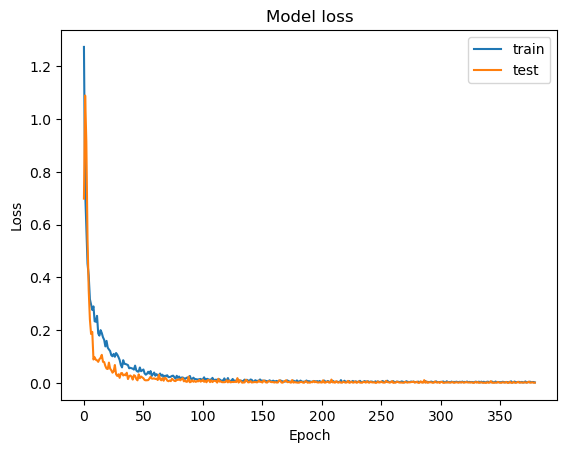

3/3 [==============================] - 0s 672us/step
MSE: 0.00
R2: 0.91
[0.8823992746038584, 0.9511821856956362, 0.9522205890440132, 0.8286041495153486, 0.7900871016613131, 0.8570314129195571, 0.9476320647087637, 0.8469185339727324, 0.7872711919639779, 0.9077433325138222]
Mean R2: 0.88 (+/- 0.06)


In [41]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from keras.layers import BatchNormalization

kfold = KFold(n_splits=10, shuffle=True, random_state=7)
cvscores = []

for train, test in kfold.split(x, y):
    # 创建模型
    model = Sequential()
    model.add(Dense(128, input_dim=input, activation='relu'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(1, activation='linear'))
    
    # 编译模型
    rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
    model.compile(loss='mean_squared_error', optimizer=rmsprop, metrics=['mean_squared_error'])
    
    # 训练模型
    early_stopping = EarlyStopping(monitor='val_loss', patience=80, verbose=2)
    history = model.fit(x, y, epochs=500, batch_size=128, shuffle=False, verbose=2,
                        validation_data=(x_test, y_test), callbacks=[early_stopping])
    
    # 绘制损失曲线
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    
    # 模型评估
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("MSE: %.2f" % mse)
    print("R2: %.2f" % r2)
    
    cvscores.append(r2)
    
print(cvscores)
print("Mean R2: %.2f (+/- %.2f)" % (np.mean(cvscores), np.std(cvscores)))

### NN

#### Ultility function

In [42]:
import torch.nn as nn
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset

class MAPELoss(nn.Module):
    def __init__(self):
        super(MAPELoss, self).__init__()

    def forward(self, output, target):
        loss = torch.mean(torch.abs((target - output) / target))
        return loss

def minmaxscaler(data):
    min_val = np.amin(data)
    max_val = np.amax(data)
    return (data - min_val) / (max_val - min_val)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

class FeatureDataset(Dataset):
    def __init__(self, x):
        self.x = x

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return torch.FloatTensor(self.x[idx])
def load_data_from_excel(train_data_file_path,test_data_file_path):
    train_data = pd.read_excel(train_data_file_path, header=0, index_col=None)
    test_data = pd.read_excel(test_data_file_path, header=0, index_col=None)
    train_features = torch.FloatTensor(train_data.drop(columns=['Tensile strength']).values)
    train_labels = torch.FloatTensor(train_data[['Tensile strength']].values)
    test_features = torch.FloatTensor(test_data.drop(columns=['Tensile strength']).values)
    test_labels = torch.FloatTensor(test_data[['Tensile strength']].values)

    return train_features, test_features, train_labels, test_labels


#### Data Load

In [43]:
import datetime
import torch.utils.data as Data
import pandas as pd
import torch
import torch.nn.functional as F    
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
#t = time.localtime()   
table = pd.DataFrame(columns=['target','batch_size','lr','module__n_hidden','module__w'])

plt.close('all')
starttime = datetime.datetime.now()
train_file_path = r'D:\creep rupture\TR+TS\TStrainingdata.xlsx'
test_file_path = r'D:\creep rupture\TR+TS\TStestingdata.xlsx'
train_features, test_features, train_labels, test_labels = load_data_from_excel(train_file_path, test_file_path)

#### network architecture

In [44]:
class Net(nn.Module):  
    def __init__(self, n_feature=9, n_hidden=218, n_output=1, w = 6):
        super(Net, self).__init__()    
        # self.BN=torch.nn.BatchNorm1d(n_hidden)#this does not help 
        self.hidden1 = torch.nn.Linear(n_feature, n_hidden) 
        nn.init.kaiming_normal_(self.hidden1.weight)#better initialize 
        
        self.hiddens = nn.ModuleList ([nn.Linear(n_hidden, n_hidden) for i in range(w)])                            
        for m in self.hiddens:
            nn.init.kaiming_normal_(m.weight)#better initialize   
        
        self.predict = torch.nn.Linear(n_hidden, n_output)  
        nn.init.kaiming_normal_(self.predict.weight)

    def forward(self, x):  
        x = self.hidden1(x)
        # x = self.BN(x)
        # x = self.Dropout (x)#this also does not help for small dataset
        x = F.relu(x)   
        
        for m in self.hiddens:
            x = m(x)
            # x = self.BN(x)
            x = F.relu(x) 
                      
        x = self.predict(x)
        # x = self.BN_3(x)
        # x = self.Dropout (x)
          # 输出值
        return x
def train(net, num_epochs, batch_size, train_features, test_features, train_labels, test_labels,
          train_loader,
          optimizer):
    print ("\n=== train begin ===")
    #print(net) #if you want to know the structure
    train_ls, test_ls = [], []
    loss = MAPELoss() # MAPE means Mean Absolute percentile error 
    for epoch in range(num_epochs):
        for x, y in train_loader:
            ls = loss(net(x).view(-1, 1), y.view(-1, 1))
            optimizer.zero_grad()
            ls.backward()
            optimizer.step()
        if epoch % 100 == 0:
            train_ls.append(loss(net(train_features).view(-1, 1), train_labels.view(-1, 1)).item())
            test_ls.append(loss(net(test_features).view(-1, 1), test_labels.view(-1, 1)).item())
            print ("epoch %d: train loss %f, test loss %f" % (epoch, train_ls[-1], test_ls[-1]))
        
    print ("=== train end ===")

  
def test(model, test_loader): 
    model.eval()
    test_loss = 0
    n = 0
    loss = MAPELoss() 
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += loss(output.view(-1, 1), target.view(-1, 1)).item()  # sum up batch loss
            n += 1

    test_loss /= n
    
    print('Test set: Average loss: {:.4f}'.format(
        test_loss))
    
    return test_loss 

def plotCurve(x_vals, y_vals, 
                        x_label, y_label, 
                        x2_vals=None, y2_vals=None, 
                        legend=None,
                        figsize=(3.5, 2.5)):
    # set figsize
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.plot(x_vals, y_vals)
    if x2_vals and y2_vals:
        plt.plot(x2_vals, y2_vals, linestyle=':')      
    if legend:
        plt.legend(legend)
        

#### Bayesian optimization for NN

In [45]:
import os
import time
from bayes_opt import BayesianOptimization
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import explained_variance_score
import matplotlib.pyplot as plt
import datetime
import pandas as pd
from torch.optim import RMSprop
def train_model(batch_size,lr, module__n_hidden,module__w):
    module__n_hidden = int(module__n_hidden) # number of neurons per layer
    module__w = int(module__w) # number of hidden layers
    batch_size = int(batch_size)
    train_dataset = Data.TensorDataset(train_features, train_labels)
    test_dataset = Data.TensorDataset(test_features, test_labels)
    train_loader = Data.DataLoader(train_dataset, batch_size, shuffle=True)
    test_loader = Data.DataLoader(test_dataset, batch_size, shuffle=True) 
    net = Net(n_feature=9, n_hidden=module__n_hidden, n_output=1, w = module__w)
    if torch.cuda.is_available():
        net = net.cuda()
    n_epochs = 1000 
    optimizer = RMSprop(net.parameters(), lr=lr, weight_decay=0.0001)
    train(net, n_epochs, batch_size,train_features, test_features, 
          train_labels, test_labels,train_loader, optimizer)
    train_loss= test(net,train_loader)
    test_loss = test(net, test_loader)

    
    r = -np.abs(train_loss-test_loss)
    
    return -test_loss

bounds = {'lr': (0.0005,0.001), 'batch_size': (32,64), 'module__n_hidden': (16,526),
          'module__w': (2,10)} #this is the bounds where you are trying to find the best parameter combination
optimizer = BayesianOptimization(
    f=train_model,
    pbounds=bounds,
    random_state=1,
)

optimizer.maximize(init_points=1, n_iter=1)#init_points is where you start and do n_iterations (n_iter) BO
print(optimizer.max)
table = pd.DataFrame(columns=['target','batch_size','lr','module__n_hidden','module__w']) #save the results into a dataframe
for res in optimizer.res:
    table=table.append(pd.DataFrame({'target':[res['target']],'batch_size':[res['params']['batch_size']],
                                     'lr':[res['params']['lr']], 'module__n_hidden':[res['params']['module__n_hidden']],
                                     'module__w':[res['params']['module__w']]}),ignore_index=True)

table=table.sort_values(by = ['target'],ascending=False)#sort the list start from the best results
model_name = 'TS_BO_NN'
file_name = '{}.xlsx'.format(model_name)
#endtime = datetime.datetime.now()
#Rtime = endtime - starttime #if it takes long time you can record it.
#print(Rtime)
table.to_excel(file_name)#save the results to the table
print(table)

|   iter    |  target   | batch_... |    lr     | module... | module__w |
-------------------------------------------------------------------------

=== train begin ===
epoch 0: train loss 0.538922, test loss 0.546599
epoch 100: train loss 0.105213, test loss 0.156642
epoch 200: train loss 0.071517, test loss 0.118584
epoch 300: train loss 0.062705, test loss 0.124646
epoch 400: train loss 0.053314, test loss 0.084209
epoch 500: train loss 0.058346, test loss 0.091346
epoch 600: train loss 0.054900, test loss 0.084625
epoch 700: train loss 0.053786, test loss 0.076685
epoch 800: train loss 0.036534, test loss 0.072890
epoch 900: train loss 0.060202, test loss 0.091057
=== train end ===
Test set: Average loss: 0.0404
Test set: Average loss: 0.0650
| 1         | -0.06505  | 45.34     | 0.0008602 | 16.06     | 4.419     |

=== train begin ===
epoch 0: train loss 0.399755, test loss 0.523129
epoch 100: train loss 0.056841, test loss 0.058738
epoch 200: train loss 0.043598, test loss 0.0531

C:\Users\zangd\AppData\Local\Temp\ipykernel_22984\3002070698.py:48: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'batch_size':[res['params']['batch_size']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_22984\3002070698.py:48: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'batch_size':[res['params']['batch_size']],


#### assess performance ofnn


=== train begin ===
Net(
  (hidden1): Linear(in_features=9, out_features=218, bias=True)
  (hiddens): ModuleList(
    (0-5): 6 x Linear(in_features=218, out_features=218, bias=True)
  )
  (predict): Linear(in_features=218, out_features=1, bias=True)
)
epoch 0: train loss 0.309344, test loss 0.311271
epoch 100: train loss 0.042397, test loss 0.090977
epoch 200: train loss 0.068437, test loss 0.065509
epoch 300: train loss 0.027371, test loss 0.046059
epoch 400: train loss 0.055327, test loss 0.062894
epoch 500: train loss 0.044929, test loss 0.049820
epoch 600: train loss 0.025763, test loss 0.027748
epoch 700: train loss 0.017588, test loss 0.025675
epoch 800: train loss 0.031226, test loss 0.023791
epoch 900: train loss 0.023225, test loss 0.032085
epoch 1000: train loss 0.022664, test loss 0.034233
epoch 1100: train loss 0.008040, test loss 0.009349
epoch 1200: train loss 0.018536, test loss 0.022159
epoch 1300: train loss 0.018236, test loss 0.020842
epoch 1400: train loss 0.022404

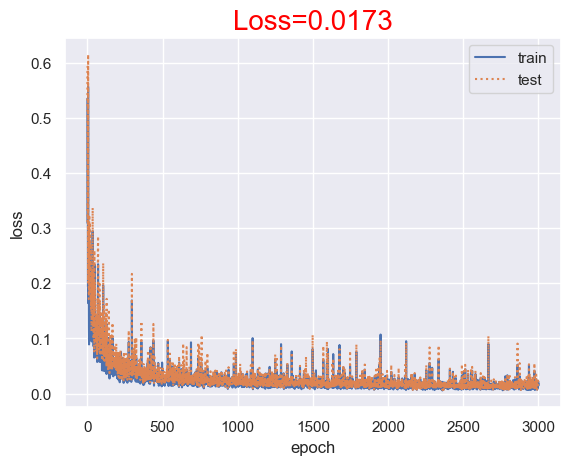

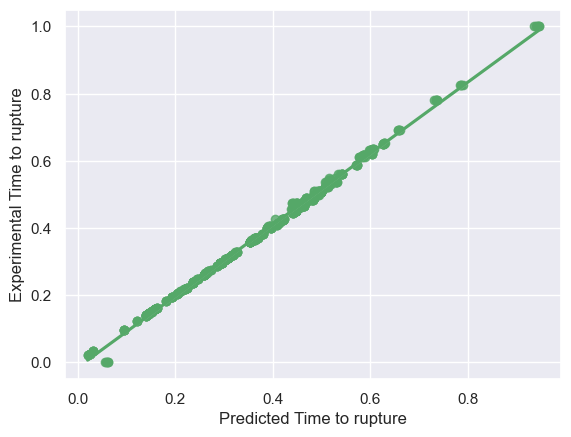

In [48]:
import seaborn as sns
sns.set(color_codes=True)
target = pd.read_excel('TS_BO_NN.xlsx')#get the best BO parameter for NN
lr = target.at[1,'lr'] 
module__n_hidden = target.at[1,'module__n_hidden']
module__w = target.at[1,'module__w']
batch_size = target.at[1,'batch_size']

module__n_hidden = int(module__n_hidden)
module__w = int(module__w)
batch_size = int(batch_size)

#get the data
train_features, test_features, train_labels, test_labels = load_data_from_excel(train_file_path, test_file_path)
train_dataset = Data.TensorDataset(train_features, train_labels)
test_dataset = Data.TensorDataset(test_features, test_labels)
train_loader = Data.DataLoader(train_dataset, batch_size, shuffle=True)
test_loader = Data.DataLoader(test_dataset, batch_size, shuffle=True) 

#train the NN with the data and paramters

print ("\n=== train begin ===")
net = Net()
print(net)
if torch.cuda.is_available():
    net = net.cuda()    
train_ls, test_ls = [], []
loss = MAPELoss() 
n_epochs = 3000
optimizer = optim.RMSprop(net.parameters(), lr=lr, weight_decay=0.0001)
for epoch in range(n_epochs):
    for x, y in train_loader:
        ls = loss(net(x).view(-1, 1), y.view(-1, 1))
        optimizer.zero_grad()
        ls.backward()
        optimizer.step()
    train_ls.append(loss(net(train_features).view(-1, 1), train_labels.view(-1, 1)).item())
    test_ls.append(loss(net(test_features).view(-1, 1), test_labels.view(-1, 1)).item())
    if epoch % 100 == 0:
        print ("epoch %d: train loss %f, test loss %f" % (epoch, train_ls[-1], test_ls[-1]))
print ("plot curves")
plotCurve(range(1, n_epochs + 1), train_ls,"epoch", "loss",range(1, n_epochs + 1), test_ls,["train", "test"])
plt.title('Loss=%.4f' % test_ls[-1], fontdict={'size': 20, 'color':  'red'})
folder_dir = 'Figures'
if not os.path.isdir(folder_dir):
  os.mkdir(folder_dir)
fig_name = 'Figures/NN_trainning history'
plt.savefig(fig_name, format='png', dpi=300)            
            
#plotting experimental results as a change of predicted TEC 
net.eval()
predict=net(x_all)
predict=predict.cpu()
predict=predict.data.numpy()  
plt.figure()
sns.regplot(x=predict, y=y_all.cpu().data.numpy(), color='g') 
plt.xlabel('Predicted Time to rupture')
plt.ylabel('Experimental Time to rupture')
fig_name_2 = 'Figures/NN_expriements and predict comparasion.png'
plt.savefig(fig_name_2, format='png', dpi=300)
  
#save the models
folder_dir = 'Model'
if not os.path.isdir(folder_dir):
  os.mkdir(folder_dir)
net_name = 'Model/TS_NN.pt'
torch.save(net.state_dict(), net_name)

#### GBDT

In [53]:
import os
import time
from bayes_opt import BayesianOptimization
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import explained_variance_score
import matplotlib.pyplot as plt
import datetime
import pandas as pd

#t = time.localtime()
model_name = 'TS_BO_GBDT'
file_name = '{}.xlsx'.format(model_name)
train_data = pd.read_excel(r'D:\creep rupture\TR+TS\TStrainingdata.xlsx')
test_data = pd.read_excel(r'D:\creep rupture\TR+TS\TStestingdata.xlsx')
train_features = train_data.drop(columns=['Tensile strength'])
train_labels = train_data[['Tensile strength']]
test_features = test_data.drop(columns=['Tensile strength'])
test_labels = test_data[['Tensile strength']]
train_features = train_features.to_numpy()
train_labels = train_labels.to_numpy()
test_features = test_features.to_numpy()
test_labels = test_labels.to_numpy()
train_labels = train_labels.reshape(-1)
test_labels = test_labels.reshape(-1)
def train_model(num_leaves,
                min_child_samples,
            learning_rate,
            n_estimators, 
            max_bin,
            colsample_bytree, 
            subsample, 
            max_depth, 
            reg_alpha,
            reg_lambda,
            min_split_gain,
            min_child_weight
            ):
    params = {
        "num_leaves": int(round(num_leaves)),
        'min_child_samples':int(round(min_child_samples)),
        'learning_rate': learning_rate,
        'n_estimators': int(round(n_estimators)),
        'max_bin': int(round(max_bin)),
        'colsample_bytree': max(min(colsample_bytree, 1), 0),
        'subsample': max(min(subsample, 1), 0),
        'max_depth': int(round(max_depth)),
        'reg_alpha':  max(reg_alpha, 0),
        'reg_lambda': max(reg_lambda, 0),
        'min_split_gain': min_split_gain,
        'min_child_weight': min_child_weight,
        'verbose': -1
                  } #the parameters you want to optimize
    model = LGBMRegressor(metric='mape',**params)
    model.fit(train_features, train_labels)
    y_pred = model.predict(test_features)
    error = -np.mean(np.abs((test_labels - y_pred) / test_labels))       # print(error)     
    return error
bounds = {'num_leaves': (5, 60),#50
          'min_child_samples':(1, 50),
          'learning_rate': (0.001, 1),
          'n_estimators': (5, 200),#100
            'max_bin': (5, 100),#10
          'colsample_bytree': (0.5, 1),
          'subsample': (0.1, 2),
          'max_depth': (1, 60),#10
          'reg_alpha': (0.01, 1), #5
          'reg_lambda': (0.01, 1),#5
          'min_split_gain': (0.001, 0.1),
          'min_child_weight': (0.0001, 30)}
optimizer = BayesianOptimization(
    f=train_model,
    pbounds=bounds,
    random_state=1,
)
optimizer.maximize(init_points = 50, n_iter=50) #here you set how many iterations you want.
table = pd.DataFrame(columns=['target', 'colsample_bytree', 'learning_rate', 'max_bin',
                      'max_depth','min_child_samples','min_child_weight','min_split_gain',
                      'n_estimators','num_leaves','reg_alpha','reg_lambda','subsample'])
for res in optimizer.res:
    table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
                                     'colsample_bytree':[res['params']['colsample_bytree']],
                                     'learning_rate':[res['params']['learning_rate']],
                                     'max_bin':[res['params']['max_bin']],
                                     'max_depth':[res['params']['max_depth']],
                                     'min_child_samples':[res['params']['min_child_samples']],
                                     'min_child_weight':[res['params']['min_child_weight']],
                                     'min_split_gain':[res['params']['min_split_gain']],
                                     'n_estimators':[res['params']['n_estimators']],
                                     'num_leaves':[res['params']['num_leaves']],
                                     'reg_alpha':[res['params']['reg_alpha']],
                                     'reg_lambda':[res['params']['reg_lambda']],
                                     'subsample':[res['params']['subsample']]}),
                                     ignore_index=True)
table=table.sort_values(by = ['target'],ascending=False)#sort the list start from the best results
table.to_excel(file_name)#save the results to the table
#endtime = datetime.datetime.now()
#print ('running time {}'.format(endtime - starttime))

|   iter    |  target   | colsam... | learni... |  max_bin  | max_depth | min_ch... | min_ch... | min_sp... | n_esti... | num_le... | reg_alpha | reg_la... | subsample |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| 1         | -0.2999   | 0.7085    | 0.7206    | 5.011     | 18.84     | 8.191     | 2.77      | 0.01944   | 72.38     | 26.82     | 0.5434    | 0.425     | 1.402     |
| 2         | -0.2034   | 0.6022    | 0.8782    | 7.602     | 40.56     | 21.45     | 16.76     | 0.0149    | 43.63     | 49.04     | 0.9686    | 0.3203    | 1.415     |
| 3         | -0.2159   | 0.9382    | 0.8947    | 13.08     | 3.304     | 9.322     | 26.34     | 0.01074   | 87.12     | 57.68     | 0.5378    | 0.695     | 0.6995    |
| 4         | -0.2242   | 0.8433    | 0.8348    | 6.737     | 45.26     | 49.45     | 22.44     | 0.02876   | 158.9     | 10.68     | 0.4534    | 0.90

| 45        | -0.3074   | 0.7259    | 0.3761    | 97.66     | 10.91     | 48.67     | 23.02     | 0.0826    | 128.4     | 41.78     | 0.4821    | 0.023     | 0.7707    |
| 46        | -0.2546   | 0.746     | 0.7304    | 49.52     | 27.99     | 7.745     | 0.3268    | 0.07607   | 67.39     | 59.14     | 0.228     | 0.3453    | 1.095     |
| 47        | -0.2535   | 0.8774    | 0.4644    | 16.86     | 19.44     | 25.72     | 20.22     | 0.07724   | 30.42     | 6.26      | 0.5239    | 0.8119    | 0.1239    |
| 48        | -0.2615   | 0.8362    | 0.6871    | 47.68     | 54.97     | 32.57     | 0.1573    | 0.04896   | 172.6     | 50.67     | 0.6527    | 0.677     | 1.199     |
| 49        | -0.2837   | 0.6371    | 0.561     | 68.81     | 21.79     | 42.94     | 5.851     | 0.07498   | 61.47     | 47.56     | 0.4335    | 0.8096    | 0.7717    |
| 50        | -0.2365   | 0.6068    | 0.7675    | 34.32     | 44.26     | 37.48     | 6.642     | 0.0222    | 43.79     | 12.84     | 0.3833    | 0.03

| 75        | -0.2832   | 0.9997    | 0.2299    | 59.68     | 31.76     | 24.93     | 20.54     | 0.08421   | 106.2     | 50.1      | 0.3901    | 0.06906   | 0.3789    |
| 76        | -0.2202   | 0.9882    | 0.7804    | 8.592     | 36.76     | 8.382     | 12.14     | 0.06493   | 115.9     | 44.93     | 0.186     | 0.5037    | 0.261     |
| 77        | -0.2742   | 0.7076    | 0.7562    | 93.09     | 5.887     | 44.28     | 7.68      | 0.09733   | 190.2     | 30.02     | 0.03236   | 0.08767   | 1.64      |
| 78        | -0.2906   | 0.8683    | 0.7915    | 77.29     | 1.155     | 48.88     | 15.49     | 0.08134   | 93.28     | 23.73     | 0.3985    | 0.07648   | 0.4663    |
| 79        | -0.232    | 0.7415    | 0.6446    | 79.93     | 23.26     | 20.19     | 7.844     | 0.00222   | 186.0     | 54.68     | 0.1814    | 0.8707    | 0.9711    |
| 80        | -0.241    | 0.7925    | 0.3679    | 66.02     | 53.7      | 35.24     | 25.5      | 0.01674   | 171.9     | 32.25     | 0.2968    | 0.02

C:\Users\zangd\AppData\Local\Temp\ipykernel_22984\702371956.py:83: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_22984\702371956.py:83: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_22984\702371956.py:83: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_22984\70

#### Assess performance of GBDT

[1] training's mape: 0.106948 valid_0's mape: 0.110166
[2] training's mape: 0.087864 valid_0's mape: 0.091423
[3] training's mape: 0.073778 valid_0's mape: 0.080713
[4] training's mape: 0.062478 valid_0's mape: 0.068726
[5] training's mape: 0.054356 valid_0's mape: 0.060541
[6] training's mape: 0.046845 valid_0's mape: 0.051128
[7] training's mape: 0.040858 valid_0's mape: 0.046156
[8] training's mape: 0.036764 valid_0's mape: 0.040736
[9] training's mape: 0.034472 valid_0's mape: 0.038932
[10] training's mape: 0.032631 valid_0's mape: 0.037201
[11] training's mape: 0.031231 valid_0's mape: 0.035881
[12] training's mape: 0.030222 valid_0's mape: 0.034293
[13] training's mape: 0.028975 valid_0's mape: 0.032257
[14] training's mape: 0.028325 valid_0's mape: 0.031470
[15] training's mape: 0.027784 valid_0's mape: 0.031356
[16] training's mape: 0.027696 valid_0's mape: 0.031253
[17] training's mape: 0.027333 valid_0's mape: 0.031015
[18] training's mape: 0.027333 valid_0's mape: 0.031015
[

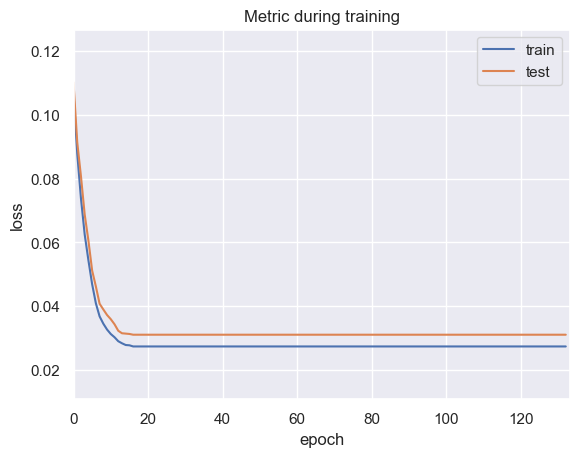

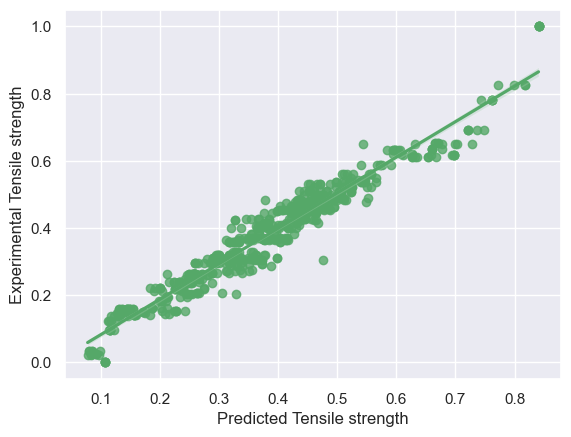

In [70]:
import lightgbm as lgb
#load the parameters of BO
target = pd.read_excel('TS_BO_GBDT.xlsx')
colsample_bytree = target.at[1,'colsample_bytree']
learning_rate = target.at[1,'learning_rate']
max_bin = target.at[1,'max_bin']
max_depth = target.at[1,'max_depth']
max_bin = target.at[1,'max_bin']
min_child_samples = target.at[1,'min_child_samples']
min_child_weight = target.at[1,'min_child_weight']
min_split_gain= target.at[1,'min_split_gain']
n_estimators = target.at[1,'n_estimators']
num_leaves = target.at[1,'num_leaves']
reg_alpha = target.at[1,'reg_alpha']
reg_lambda = target.at[1,'reg_lambda']
subsample = target.at[1,'subsample']
params = {
    "num_leaves": int(round(num_leaves)),
    'min_child_samples':int(round(min_child_samples)),
    'learning_rate': learning_rate,
    'n_estimators': int(round(n_estimators)),
    'max_bin': int(round(max_bin)),
    'colsample_bytree': max(min(colsample_bytree, 1), 0),
    'subsample': max(min(subsample, 1), 0),
    'max_depth': int(round(max_depth)),
    'reg_lambda':  max(reg_lambda, 0),
    'reg_alpha': max(reg_alpha, 0),
    'min_split_gain': min_split_gain,
    'min_child_weight': min_child_weight,
    'objective': 'regression',
    'verbose': -1
              }
train_data = pd.read_excel(r'D:\creep rupture\TR+TS\TStrainingdata.xlsx')
test_data = pd.read_excel(r'D:\creep rupture\TR+TS\TStestingdata.xlsx')
train_features = train_data.drop(columns=['Tensile strength'])
train_labels = train_data[['Tensile strength']]
test_features = test_data.drop(columns=['Tensile strength'])
test_labels = test_data[['Tensile strength']]
train_features = train_features.to_numpy()
train_labels = train_labels.to_numpy()
test_features = test_features.to_numpy()
test_labels = test_labels.to_numpy()
train_labels = train_labels.reshape(-1)
test_labels = test_labels.reshape(-1) 
model = LGBMRegressor(metric='mape', **params)
model.fit(train_features, train_labels, eval_set=[(test_features, test_labels), (train_features, train_labels)],
          eval_metric='mape')

evals_result = model.evals_result_
train_mape = evals_result['training']['mape']
valid_mape = evals_result['valid_0']['mape']

for epoch, (train_mape_value, valid_mape_value) in enumerate(zip(train_mape, valid_mape), start=1):
    print(f"[{epoch}] training's mape: {train_mape_value:.6f} valid_0's mape: {valid_mape_value:.6f}")
#plot the traiining history
lgb.plot_metric(model)
plt.ylabel('loss')
plt.xlabel ('epoch')
plt.legend(['train','test'])
folder_dir = 'Figures'
if not os.path.isdir(folder_dir):
  os.mkdir(folder_dir)
plt.savefig('Figures/GBDT_trainning history.png', format='png', dpi=300)
#plotting experimental results as a change of predicted TEC 
plt.figure()
predict = model.predict(x_all.cpu().data.numpy())
sns.set_style("darkgrid")
sns.regplot(x=predict, y=y_all.cpu().data.numpy(), color='g') 
plt.xlabel ('Predicted Tensile strength')
plt.ylabel('Experimental Tensile strength')
plt.savefig('Figures/GBDT_expriements and predict comparasion.png', format='png', dpi=300)
#save the models
folder_dir = 'Model'
if not os.path.isdir(folder_dir):
  os.mkdir(folder_dir)
net_name = 'Model/TS_GBDT.pt'
torch.save(net.state_dict(), net_name)


## XGBoost

In [1]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import numpy as np
import pandas as pd

In [2]:
train_data = pd.read_excel(r'D:\creep rupture\TR+TS\normalizedtrainingdataTF.xlsx')
test_data = pd.read_excel(r'D:\creep rupture\TR+TS\normalizedtestingdataTF.xlsx')
train_data = train_data.dropna(subset=['Tensile strength'])
test_data = test_data.dropna(subset=['Tensile strength'])
x = train_data.drop(columns=[ 'Tensile strength'])
y = train_data['Tensile strength']
x_test = test_data.drop(columns=['Tensile strength'])
y_test = test_data['Tensile strength']

In [3]:
# 定义你希望调优的参数范围
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [4, 5, 6],
    'n_estimators': [50, 100, 150],
    'gamma': [0, 0.1, 0.2],
    'alpha': [0, 0.1, 0.2],
    'lambda': [0, 0.1, 0.2]
}

# 创建XGBoost回归模型实例
xgb_reg = xgb.XGBRegressor(objective ='reg:squarederror')

# 将模型和参数范围传入 GridSearchCV，并设置交叉验证数量为 5
grid_search = GridSearchCV(xgb_reg, param_grid, cv=5, scoring='neg_mean_squared_error')

# 使用训练数据拟合 GridSearchCV
grid_search.fit(x, y)

# 打印最佳参数组合
print(f"Best parameters: {grid_search.best_params_}")

# 使用最优参数在所有训练数据上重新训练模型
best_xgb_reg = grid_search.best_estimator_

# 如果使用xgb.train，则需使用以下代码
dtrain = xgb.DMatrix(x, label=y)
dtest = xgb.DMatrix(x_test, label=y_test)

# 设置参数（使用上面GridSearchCV得到的最优参数）
best_params = grid_search.best_params_
best_params["objective"] = "reg:squarederror"

bst = xgb.train(best_params,
                dtrain,
                num_boost_round=100,
                evals=[(dtest, "test")],
                early_stopping_rounds=10,
                verbose_eval=False)

# 对测试集进行预测
preds = best_xgb_reg.predict(x_test)

# 计算并打印均方误差和确定系数（R-squared）
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE: %f" % (rmse))
print("R2: %f" % (r2))

Best parameters: {'alpha': 0, 'gamma': 0, 'lambda': 0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 150}
RMSE: 0.017176
R2: 0.987373


C:\Users\zangd\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:160: UserWarning: [20:34:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0cec3277c4d9d0165-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


## MLP

In [4]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import numpy as np

In [5]:
# 创建多层感知机回归模型实例
mlp_regressor = MLPRegressor(random_state=42, max_iter=1000)

# 定义参数网格
param_grid = {
    'hidden_layer_sizes': [(10,), (20,), (10,10)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01]
}

# 定义评分函数
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# 使用 GridSearchCV 进行参数优化
grid_search = GridSearchCV(mlp_regressor, param_grid, scoring=mse_scorer, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(x, y)

# 打印找到的最佳参数
print(f"Best parameters found: {grid_search.best_params_}")

# 使用最佳参数重新训练模型
best_mlp = grid_search.best_estimator_

# 模型预测
y_pred = best_mlp.predict(x_test)

# 评估模型
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'The rmse of prediction is: {rmse}')
print(f'The R^2 score of prediction is: {r2}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (20,), 'solver': 'lbfgs'}
The rmse of prediction is: 0.016466684075457427
The R^2 score of prediction is: 0.9883936731156049


## PSO optimization for XGBoost

In [6]:
from pyswarm import pso
from sklearn.metrics import mean_squared_error

In [7]:
train_data = pd.read_excel(r'D:\creep rupture\TR+TS\normalizedtrainingdataTF.xlsx')
test_data = pd.read_excel(r'D:\creep rupture\TR+TS\normalizedtestingdataTF.xlsx')
train_data = train_data.dropna(subset=['Tensile strength'])
test_data = test_data.dropna(subset=['Tensile strength'])
x_train = train_data.drop(columns=[ 'Tensile strength'])
y_train = train_data['Tensile strength']
x_test = test_data.drop(columns=['Tensile strength'])
y_test = test_data['Tensile strength']

In [8]:
def objective_func(particle_position):
    max_depth = int(particle_position[0])
    learning_rate = particle_position[1]
    n_estimators = int(particle_position[2])
    min_child_weight = int(particle_position[3])
    subsample = particle_position[4]
    gamma = particle_position[5]

    model = xgb.XGBRegressor(max_depth=max_depth,
                             learning_rate=learning_rate,
                             n_estimators=n_estimators,
                             min_child_weight=min_child_weight,
                             subsample=subsample,
                             gamma=gamma)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [9]:
lb = [1, 0.001, 50, 1, 0.1, 0]
ub = [10, 0.5, 500, 10, 1, 1]

xopt, fopt = pso(objective_func, lb, ub, swarmsize=30, maxiter=100)
print('Found optimal solution: ', xopt)
print('Objective function at optimal solution: ', fopt)

Stopping search: Swarm best objective change less than 1e-08
Found optimal solution:  [9.92594757e+00 9.94963420e-02 2.38960465e+02 1.31773116e+00
 2.56316842e-01 0.00000000e+00]
Objective function at optimal solution:  0.0001350952946528547


In [10]:
max_depth = int(xopt[0])
learning_rate = xopt[1]
n_estimators = int(xopt[2])
min_child_weight = int(xopt[3])
subsample = xopt[4]
gamma = xopt[5]

model_optimal = xgb.XGBRegressor(max_depth=max_depth,
                                 learning_rate=learning_rate,
                                 n_estimators=n_estimators,
                                 min_child_weight=min_child_weight,
                                 subsample=subsample,
                                 gamma=gamma)
model_optimal.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.09949634197026774,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=238, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

# 预测 x_test
y_pred = model_optimal.predict(x_test)

# 评估模型性能
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Mean Absolute Error (MAE): {mae:.5f}")
print(f"R2 Score: {r2:.5f}")

Mean Squared Error (MSE): 0.00014
Mean Absolute Error (MAE): 0.00845
R2 Score: 0.99422


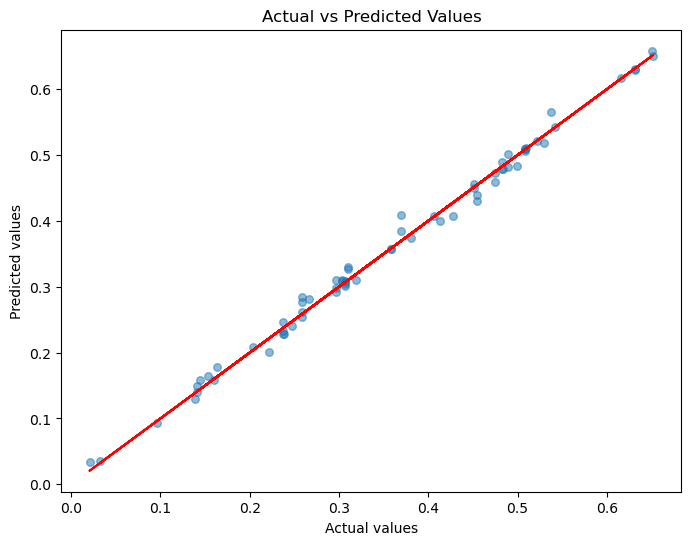

In [13]:
import matplotlib.pyplot as plt

# Draw scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, s=30, alpha=0.5)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')

# Draw line for perfect predictions
plt.plot(y_test, y_test, 'r')

plt.show()